# Applying the pipeline to C-MAPSS

This notebook runs the MahaKNN against **C-MAPSS** (Saxena et al., PHM 2008), NASA's
simulated turbofan run-to-failure data. Four subsets, each a fleet of engines of one type,
sampled once per operational cycle.

The dataset is a *prognostics* benchmark rather than an anomaly-detection one, and the
difference shows up immediately in what ships as ground truth. SMD came with a `0`/`1` per
test row. C-MAPSS comes with one integer per test engine - the number of cycles it would
have survived past the end of its record - and nothing per row at all. Point labels have to
be derived, which is what the labelling cell below does.

It also means the roles the two files were shipped with are the wrong way round for this
task, and this notebook swaps them.


## 1. The data

Each subset is three plain-text files of space-separated numbers, 26 columns wide and no
header:

| file | contents |
|---|---|
| `train_FDxxx.txt` | one row per engine-cycle, run **to failure** |
| `test_FDxxx.txt` | same shape, same fleet, each record **truncated** before failure |
| `RUL_FDxxx.txt` | one integer per test engine: cycles remaining after its last row |

The columns are `unit`, `cycle`, three operational settings, then 21 sensor measurements.
Rows carry a trailing space, so a naive whitespace split yields a 27th all-empty column that
has to be dropped.

Every engine starts with unknown initial wear and manufacturing variation - normal, per the
readme, and not a fault - then develops a fault at an undisclosed cycle which grows until
failure. So the corpus of normality is not a file here as it was in SMD, but the early
portion of each trajectory, and where "early" ends is a modelling choice rather than
something the data states.


### Which half is the corpus

C-MAPSS was built for remaining-life regression, and its file names carry that task's
convention: fit on complete lifetimes, predict on censored ones. For detection the two
halves are wanted the other way round, and **this notebook swaps them**.

The argument is what each half contains. A detector needs a corpus of normality to learn
from and a labelled set of failures to be scored against, and the shipped names put both in
the wrong place:

| shipped as | what it holds | used here as |
|---|---|---|
| `test_FDxxx.txt` | records cut off before failure - mostly healthy, and only a quarter of its engines ever reach the horizon at all | **corpus** |
| `train_FDxxx.txt` | every engine driven to failure, so every one contains a degradation event | **evaluation** |

Two consequences, both favourable. The evaluation set goes from 25 engines out of 100
carrying an anomaly to all 100 carrying one, which is the difference between a scoring set
that is mostly negatives and one that actually exercises the detector. And its labels get
better: remaining life in the run-to-failure half is read off the record itself, whereas in
the truncated half it depends on `RUL_FDxxx.txt` being right.

Two things this does *not* buy. The truncated half is not clean merely by virtue of being
truncated - a few per cent of its rows still sit inside the horizon, so the corpus rule below
has to filter it rather than take it wholesale. And no published C-MAPSS number is
comparable to anything computed here; that comparability was already gone the moment the
task stopped being RUL regression.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import iisignature
import faiss

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT / 'src'))

from anomalies_scale.signature_computer import add_base_point
from anomalies_scale.anomaly_detection_pooled import (
    PooledCorpus, build_whitening, split_corpus)
from anomalies_scale.covariance_creation import covariance_matrix

CMAPSS = PROJECT / 'CMAPSS'
SUBSETS = ('FD001', 'FD002', 'FD003', 'FD004')

SETTINGS = ['setting{0}'.format(i) for i in (1, 2, 3)]
SENSORS = ['sensor{0}'.format(i) for i in range(1, 22)]
CHANNELS = SETTINGS + SENSORS
COLUMNS = ['unit', 'cycle'] + CHANNELS


def read_table(kind, subset):
    """Read one `{kind}_{subset}.txt` into a named frame.

    `kind` names the *file*, not the role it plays here - see `load_subset`. Every row ends
    in a space, so splitting on whitespace produces a trailing column that is empty on every
    row; `dropna` removes it before the names are attached.
    """
    frame = pd.read_csv(CMAPSS / '{0}_{1}.txt'.format(kind, subset),
                        sep=r'\s+', header=None, engine='python')
    frame = frame.dropna(axis=1, how='all')
    frame.columns = COLUMNS
    return frame


def load_subset(subset):
    """Return one subset as `(corpus, evaluation)`, each with a per-cycle `rul` column.

    **The roles are swapped relative to the file names.** `test_FDxxx.txt` becomes the
    corpus and `train_FDxxx.txt` becomes the evaluation set, for the reasons set out above.
    The local names below say which file each frame came from, so that the swap happens once,
    visibly, at the return statement, and nothing downstream has to remember it.

    The two halves need different arithmetic for `rul`. A run-to-failure record ends at
    failure, so remaining life at any cycle is simply what is left of the record. A truncated
    record stops early, and `RUL_FDxxx.txt` supplies exactly the piece that was cut off - so
    its remaining life is that final figure plus the cycles still to come in the record.
    """
    to_failure = read_table('train', subset)
    truncated = read_table('test', subset)

    final = pd.read_csv(CMAPSS / 'RUL_{0}.txt'.format(subset),
                        sep=r'\s+', header=None, engine='python').iloc[:, 0]
    final.index = range(1, len(final) + 1)      # truncated units are numbered 1..N in order

    to_failure['rul'] = to_failure.groupby('unit').cycle.transform('max') - to_failure.cycle
    truncated['rul'] = (truncated.unit.map(final)
                        + truncated.groupby('unit').cycle.transform('max') - truncated.cycle)

    return truncated, to_failure


DATA = {subset: load_subset(subset) for subset in SUBSETS}

print('{0:<8}{1:>26}{2:>26}{3:>10}'.format(
    '', '--- corpus (truncated) ---', '- evaluation (to failure) -', ''))
print('{0:<8}{1:>10}{2:>8}{3:>8}{4:>10}{5:>8}{6:>8}{7:>10}'.format(
    'subset', 'engines', 'rows', 'cyc/unit', 'engines', 'rows', 'cyc/unit', 'constant'))
for subset, (corpus, evaluation) in DATA.items():
    describe = lambda f: (f.unit.nunique(), len(f), '{0}-{1}'.format(
        f.groupby('unit').size().min(), f.groupby('unit').size().max()))
    print('{0:<8}{1:>10}{2:>8,}{3:>8}{4:>10}{5:>8,}{6:>8}{7:>10}'.format(
        subset, *describe(corpus), *describe(evaluation),
        int((corpus[CHANNELS].std().to_numpy() == 0).sum())))


        --- corpus (truncated) ---- evaluation (to failure) -          
subset     engines    rowscyc/unit   engines    rowscyc/unit  constant
FD001          100  13,096  31-303       100  20,631 128-362         4
FD002          259  33,991  21-367       260  53,759 128-378         0
FD003          100  16,596  38-475       100  24,720 145-525         4
FD004          248  41,214  19-486       249  61,249 128-543         0


In [2]:
# C-MAPSS states no fault onset, so a point label has to be declared. The convention this
# follows is the piecewise-linear RUL target standard in the prognostics literature: sensor
# response to damage is not considered observable until roughly the last 125-130 cycles,
# and everything above that knee is treated as flat health.
#
# Two cuts rather than one, deliberately. Anything with more than CORPUS_RUL_FLOOR cycles
# left is the safest available proxy for normal and is what the corpus may be built from;
# anything inside HEALTH_HORIZON is what the detector is asked to find. The band between
# them is neither, and is left out of both rather than forced into one.
#
# The corpus floor is 50, not the 125-130 knee. That is a deliberate trade and it cuts both
# ways. It roughly doubles the corpus - the strict floor left 17 of 100 engines contributing
# no window at all, because their healthy stretch was shorter than one window - and a larger,
# more varied corpus of normality is exactly what a nearest-neighbour detector wants.
#
# What it risks is the opposite error. Cycles between 50 and 130 sit inside the region the
# piecewise-linear convention says damage is already observable in, so some genuinely
# degrading behaviour will now be learnt as normal. If that happens it costs recall, and it
# would show up as the detector firing later than it used to. Worth watching in the warning
# times rather than assuming either way.
HEALTH_HORIZON = 30
CORPUS_RUL_FLOOR = 50

for subset, (corpus, evaluation) in DATA.items():
    for frame in (corpus, evaluation):
        frame['degraded'] = frame.rul <= HEALTH_HORIZON
        frame['healthy'] = frame.rul > CORPUS_RUL_FLOOR

    carries = evaluation.groupby('unit').degraded.any()
    print('{0}  corpus: {1:>6,} usable rows ({2:>5.1%}), {3:>4.1%} of the half discarded as '
          'inside the horizon   |   evaluation: {4:>5.1%} degraded, {5:>3}/{6} engines '
          'carry a failure'.format(
              subset, int(corpus.healthy.sum()), corpus.healthy.mean(),
              corpus.degraded.mean(), evaluation.degraded.mean(),
              int(carries.sum()), len(carries)))


FD001  corpus: 12,210 usable rows (93.2%), 2.5% of the half discarded as inside the horizon   |   evaluation: 15.0% degraded, 100/100 engines carry a failure
FD002  corpus: 31,405 usable rows (92.4%), 3.2% of the half discarded as inside the horizon   |   evaluation: 15.0% degraded, 260/260 engines carry a failure
FD003  corpus: 15,817 usable rows (95.3%), 1.8% of the half discarded as inside the horizon   |   evaluation: 12.5% degraded, 100/100 engines carry a failure
FD004  corpus: 38,964 usable rows (94.5%), 2.1% of the half discarded as inside the horizon   |   evaluation: 12.6% degraded, 249/249 engines carry a failure


### A corpus engine against an evaluation engine

The two halves are drawn from the same fleet and differ in one respect only: where the
recording stops. Plotting one of each shows what the swap buys - the corpus engine is flat
for its whole record, while the evaluation engine carries the drift the detector is meant
to find, and carries it in a labelled place.


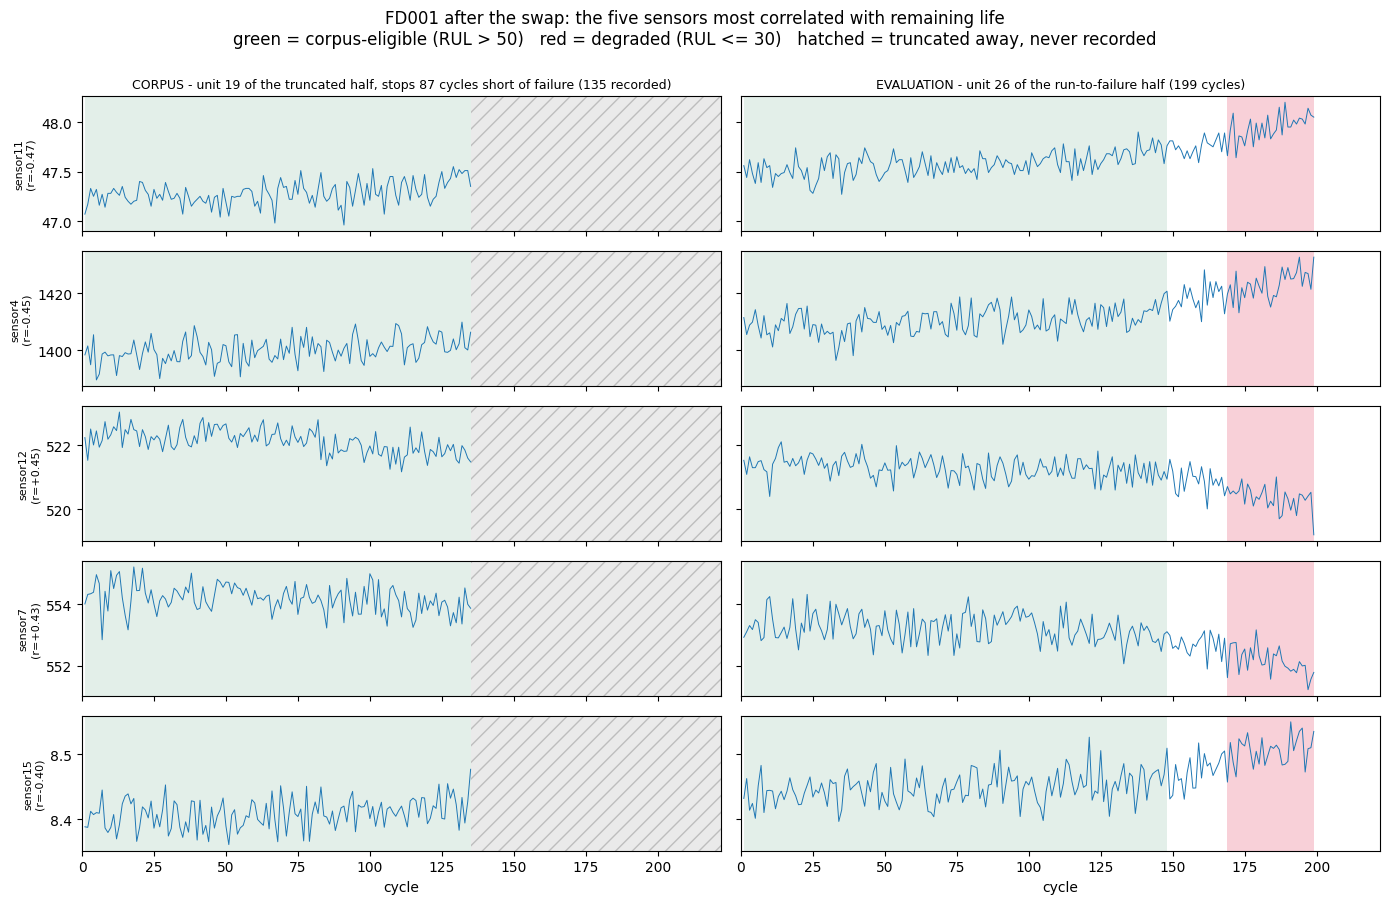

corpus      unit  19: 135 cycles recorded, RUL 221 ->  87, 135 corpus-eligible,   0 degraded
evaluation  unit  26: 199 cycles recorded, RUL 198 ->   0, 148 corpus-eligible,  31 degraded


In [3]:
corpus, evaluation = DATA['FD001']

# Which sensors carry the degradation? Ranked on the corpus half, which is the only half a
# detector is allowed to look at, so the choice of what to plot leaks nothing from the
# evaluation set. Ranked on magnitude but kept signed: the sign says which way a sensor moves
# as life runs out, and one that falls toward failure is as informative as one that rises.
# The constant channels go first - a zero-variance column has no correlation to rank.
varying = [c for c in CHANNELS if corpus[c].std() > 0]
informative = corpus[varying].corrwith(corpus.rul)
SHOW = list(informative.abs().sort_values(ascending=False).index[:5])

# One representative engine from each half: median remaining life at the cut for the corpus,
# median lifetime for the evaluation set. Nothing hinges on the choice, but a median engine
# is a fairer picture than the most extreme one.
cut_at = corpus.groupby('unit').rul.min()
lifetime = evaluation.groupby('unit').size()
CORPUS_UNIT = int((cut_at - cut_at.median()).abs().idxmin())
EVAL_UNIT = int((lifetime - lifetime.median()).abs().idxmin())

one_corpus = corpus[corpus.unit == CORPUS_UNIT]
one_eval = evaluation[evaluation.unit == EVAL_UNIT]
missing = int(cut_at[CORPUS_UNIT])            # cycles the corpus record never shows
span = max(len(one_corpus) + missing, len(one_eval))


def bands(engine):
    """Corpus-eligible and degraded spans of one engine, as (lo, hi) cycle pairs.

    `rul` falls monotonically with cycle, so each mask is one contiguous run and its
    endpoints are enough to describe it.
    """
    out = []
    for mask in (engine.rul > CORPUS_RUL_FLOOR, engine.rul <= HEALTH_HORIZON):
        cycles = engine.cycle[mask]
        out.append((cycles.min(), cycles.max()) if len(cycles) else None)
    return out


panels = (
    (one_corpus, missing, 'CORPUS - unit {0} of the truncated half, stops {1} cycles short '
                          'of failure ({2} recorded)'.format(
                              CORPUS_UNIT, missing, len(one_corpus))),
    (one_eval, 0, 'EVALUATION - unit {0} of the run-to-failure half ({1} cycles)'.format(
        EVAL_UNIT, len(one_eval))),
)

fig, axes = plt.subplots(len(SHOW), 2, figsize=(14, 9), sharex=True, sharey='row')

for column, (engine, truncated_by, title) in enumerate(panels):
    healthy_band, degraded_band = bands(engine)

    for row, channel in enumerate(SHOW):
        ax = axes[row, column]
        ax.plot(engine.cycle, engine[channel], lw=0.7, color='#1f77b4')

        if healthy_band:
            ax.axvspan(*healthy_band, color='seagreen', alpha=0.13, lw=0)
        if degraded_band:
            ax.axvspan(*degraded_band, color='crimson', alpha=0.20, lw=0)
        if truncated_by:                      # the part of this engine's life never recorded
            ax.axvspan(len(engine), len(engine) + truncated_by, facecolor='0.85',
                       alpha=0.55, lw=0, hatch='//', edgecolor='0.6')

        ax.set_xlim(0, span)
        if row == 0:
            ax.set_title(title, fontsize=9)
        if column == 0:
            ax.set_ylabel('{0}\n(r={1:+.2f})'.format(channel, informative[channel]), fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('cycle')

fig.suptitle('FD001 after the swap: the five sensors most correlated with remaining life\n'
             'green = corpus-eligible (RUL > {0})   red = degraded (RUL <= {1})   '
             'hatched = truncated away, never recorded'.format(
                 CORPUS_RUL_FLOOR, HEALTH_HORIZON), y=1.0)
plt.tight_layout()
plt.show()

for role, engine in (('corpus', one_corpus), ('evaluation', one_eval)):
    print('{0:<11} unit {1:>3}: {2:>3} cycles recorded, RUL {3:>3} -> {4:>3}, '
          '{5:>3} corpus-eligible, {6:>3} degraded'.format(
              role, engine.unit.iloc[0], len(engine), engine.rul.max(), engine.rul.min(),
              int(engine.healthy.sum()), int(engine.degraded.sum())))


## 2. From engines to streams

Two things have to happen before a signature can be taken, and neither is optional here.

**Fixed-length windows.** Engines run anywhere from 19 to 543 cycles. A pooled corpus
compares intervals by *depth*, and depth is a relative width - so depth 3 of a 128-cycle
engine is 16 cycles while depth 3 of a 543-cycle engine is 68. Pooling those into one
reference set would band together intervals with nothing in common but their position in a
tree. Windowing to a fixed length makes depth mean a fixed number of cycles again, and as a
side effect solves the variable-length problem that would otherwise block stacking.

`WINDOW = 33` rather than 32 so that the dyadic grid is exact: 33 points give 32 steps, which
`GRANULARITY = 3` divides into 8 cells of 4 cycles with every boundary landing on a real
sample. At stride 16 the shortest engines still yield windows, and only a handful of the
shortest test records are lost.

**Normalisation.** This is the difference from SMD that matters most. SMD arrived pre-scaled
to [0, 1] and its notebook noted that the `normalise` stage was therefore unnecessary. Here
the sensors span from about -0.009 to 9,245 in the same table. Left alone, the largest
channels would dominate every signature term they appear in, the level-2 areas would be
swamped, and composing intervals through Chen's identity would lose most of the available
significant digits. The scaler is fitted on the **corpus half only, healthy rows only**, and
applied unchanged to both halves - so evaluation values are free to fall outside [0, 1],
which is signal rather than a problem.


In [4]:
WINDOW, STRIDE = 33, 16        # 33 points = 32 steps = 8 dyadic cells of 4 cycles
TRUNC, GRANULARITY = 2, 3

SUBSET = 'FD001'
corpus_half, eval_half = DATA[SUBSET]


def fit_scaler(frame):
    """Per-channel min-max fitted on corpus-eligible rows only.

    A channel that never moves has zero span; dividing by 1 instead sends it to a constant
    0.0. It is kept rather than dropped, following the pipeline: a zero-variance direction is
    annihilated by the pseudo-inverse rather than amplified by it, so it contributes nothing
    to the Mahalanobis distance instead of dividing by zero in it.
    """
    usable = frame[frame.healthy]
    low = usable[CHANNELS].min()
    span = (usable[CHANNELS].max() - low).replace(0.0, 1.0)
    return low, span


LOW, SPAN = fit_scaler(corpus_half)
inert = [c for c in CHANNELS if SPAN[c] == 1.0
         and corpus_half.loc[corpus_half.healthy, c].nunique() == 1]

print('scaler fitted on {0:,} corpus-eligible rows'.format(int(corpus_half.healthy.sum())))
print('{0} of {1} channels never move in the corpus: {2}'.format(
    len(inert), len(CHANNELS), ', '.join(inert)))

# A channel dead in the corpus but live in evaluation would be a blind spot: its signature
# terms would be constant across the corpus, the whitening would annihilate that direction,
# and any anomaly expressed there would be invisible. Worth checking rather than assuming.
live_elsewhere = [c for c in inert if eval_half[c].std() > 1e-9]
print('...of which {0} move in the evaluation half: {1}'.format(
    len(live_elsewhere), live_elsewhere or 'none - they are inert in both halves'))


def make_windows(frame, healthy_only):
    """Slice one half into fixed-length windows, never crossing an engine boundary.

    `healthy_only` is what separates the two uses. The corpus takes only windows lying wholly
    inside the corpus-eligible region, so nothing the detector learns as normal is drawn from
    a degrading engine. The evaluation half takes every window, because the detector has to
    be scored on the healthy stretches as well as the failing ones.

    `global_start` locates each window in the half concatenated in (unit, cycle) order, which
    is what lets a flagged interval - reported in window-local point indices - be rasterised
    back onto the labelled series.

    Returns the `(n_windows, WINDOW, 1 + n_channels)` path block and a matching index frame.
    """
    frame = frame.sort_values(['unit', 'cycle'])
    blocks, index, base = [], [], 0

    for unit, engine in frame.groupby('unit', sort=True):
        values = ((engine[CHANNELS] - LOW) / SPAN).to_numpy()
        rul = engine.rul.to_numpy()
        cycles = engine.cycle.to_numpy()
        length = len(engine)

        starts = list(range(0, length - WINDOW + 1, STRIDE))
        # Anchor a last window on the engine's final cycle. Without it the closing STRIDE-1
        # cycles of every record fall in no window at all - and on the run-to-failure half
        # those are precisely the most degraded cycles there are, so the detector would be
        # scored on a series whose worst part it was never shown.
        if starts and starts[-1] + WINDOW < length:
            starts.append(length - WINDOW)

        for lo in starts:
            window = slice(lo, lo + WINDOW)
            if healthy_only and not (rul[window] > CORPUS_RUL_FLOOR).all():
                continue

            # Sensor values only - no time channel. Every window is the same length and was
            # time-normalised identically, so the time channel was bit-for-bit identical in
            # every one of them: its level-1 term is a constant and discriminates nothing.
            # What it did carry is the level-2 cross terms - the signed area of each value
            # channel against time, which is where trend and direction live - and this run
            # asks whether those were earning their 48 terms.
            #
            # Dropping it also makes the signature invariant to reparametrisation: two
            # windows tracing the same path at different rates now sign identically.
            blocks.append(values[window].copy())
            index.append({'unit': int(unit), 'start_cycle': int(cycles[lo]),
                          'min_rul': int(rul[window].min()), 'global_start': base + lo})
        base += length

    paths = np.stack(blocks)
    index = pd.DataFrame(index)
    index['degraded'] = index.min_rul <= HEALTH_HORIZON
    return paths, index


corpus_paths, corpus_index = make_windows(corpus_half, healthy_only=True)
eval_paths, eval_index = make_windows(eval_half, healthy_only=False)

width = corpus_paths.shape[2]
print('corpus     {0:>5} windows from {1:>3} engines'.format(
    len(corpus_paths), corpus_index.unit.nunique()))
print('evaluation {0:>5} windows from {1:>3} engines, {2} degraded ({3:.1%})'.format(
    len(eval_paths), eval_index.unit.nunique(), int(eval_index.degraded.sum()),
    eval_index.degraded.mean()))
print('\npath width {0} ({1} sensor/setting channels, no time channel), signature terms '
      'at truncation {2}: {3}'.format(
          width, len(CHANNELS), TRUNC, iisignature.siglength(width, TRUNC)))
print('with a time channel it would be {0} terms - the difference is the {1} level-2 cross '
      'terms between time and the values'.format(
          iisignature.siglength(width + 1, TRUNC),
          iisignature.siglength(width + 1, TRUNC) - iisignature.siglength(width, TRUNC)))


scaler fitted on 12,210 corpus-eligible rows
7 of 24 channels never move in the corpus: setting3, sensor1, sensor5, sensor10, sensor16, sensor18, sensor19
...of which 0 move in the evaluation half: none - they are inert in both halves
corpus       671 windows from  99 engines
evaluation  1235 windows from 100 engines, 289 degraded (23.4%)

path width 24 (24 sensor/setting channels, no time channel), signature terms at truncation 2: 600
with a time channel it would be 650 terms - the difference is the 50 level-2 cross terms between time and the values


## 3. All dyadic intervals, and their unions

`create_corpus_merged` builds the dyadic *tree*: the whole stream, its two halves, its four
quarters, down to `2 ** -granularity`. At granularity 3 that is 15 intervals per stream.

The tree alone leaves a gap. The widest-first search does not only ask about tree nodes - as
it extends a clean block outward it produces intervals that are contiguous runs of adjacent
cells, and a run of three cells is not a dyadic node at all. `PooledCorpus.depth_for_width`
currently handles those by *approximation*, mapping the query's relative width to the nearest
depth that exists, so a 3-cell interval is scored against a corpus containing only 2-cell and
4-cell ones. The reference set is then systematically the wrong width.

Closing the gap means adding the unions, and the tidy way to say which unions is:

> every interval whose two endpoints both lie on the finest dyadic grid.

That single description subsumes the tree - each dyadic node is a run of aligned cells - and
adds every run that is not aligned or not a power of two. With 8 cells it is
`8 x 9 / 2 = 36` intervals per stream against the tree's 15.

Cost is not the issue; Chen's identity makes it nearly free. The 8 leaf signatures are
computed once, and then every run is built by extending the previous one by a single
`sigcombine`, so the whole set costs 36 combines rather than 36 signature computations.

Depths are assigned by the same nearest-log2 rule `depth_for_width` uses at query time, so a
run of *k* cells out of 8 lands at `round(3 - log2 k)`. Corpus and query agree by
construction, and the bands that were previously empty of odd widths are now populated by
genuine intervals of that width.


In [5]:
def grid_signatures(path, trunc=TRUNC, granularity=GRANULARITY):
    """Base-pointed signature of every interval with both endpoints on the dyadic grid.

    Emits the dyadic tree and every union of adjacent dyadic cells - `2**granularity` cells
    give `C(cells + 1, 2)` intervals. Drop-in shaped like
    `create_corpus_merged.dyadic_signatures`: a list of `(depth, lo, hi, signature)` with `lo`
    and `hi` inclusive point indices, so adjacent intervals share a boundary point and
    composing them introduces no discontinuity.

    Each run is built from the previous one by a single `sigcombine`, which is exact by Chen's
    identity, so the cost is one combine per interval rather than one signature per interval.
    """
    path = np.asarray(path, dtype=float)
    length, width = path.shape
    cells = 2 ** granularity
    if length < cells + 1:
        raise ValueError('need at least {0} points for {1} dyadic cells, got {2}'.format(
            cells + 1, cells, length))

    edges = np.linspace(0, length - 1, cells + 1).round().astype(int)
    leaves = [iisignature.sig(path[edges[c]:edges[c + 1] + 1], trunc) for c in range(cells)]

    records = []
    for first in range(cells):
        running = None
        for last in range(first, cells):
            running = (leaves[last] if running is None else
                       iisignature.sigcombine(running, leaves[last], width, trunc))
            lo, hi = int(edges[first]), int(edges[last + 1])
            depth = int(round(granularity - np.log2(last - first + 1)))
            records.append((depth, lo, hi, add_base_point(running, path[lo], width, trunc)))

    records.sort(key=lambda record: (record[0], record[1]))
    return records


# Chen composition is exact in exact arithmetic, so any disagreement with a directly computed
# signature is pure floating-point loss. Measured two ways: over the whole set, where a run of
# 8 cells has been through 7 combines, and over 2-cell runs, which have been through exactly
# one. If the second is already at the first's level then this is a floor rather than an
# accumulation, and composing more pieces is not what costs the digits.
sample = corpus_paths[0]
worst = {1: 0.0, 7: 0.0}
for depth, lo, hi, composed in grid_signatures(sample):
    combines = (hi - lo) // 4 - 1
    if combines not in worst:
        continue
    direct = add_base_point(iisignature.sig(sample[lo:hi + 1], TRUNC), sample[lo], width, TRUNC)
    worst[combines] = max(worst[combines], float(np.abs(composed - direct).max()
                                                 / max(np.abs(direct).max(), 1e-30)))

records = grid_signatures(sample)
print('{0} intervals per window, against {1} for the dyadic tree alone'.format(
    len(records), 2 ** (GRANULARITY + 1) - 1))
print('\nrelative disagreement, composed against directly computed:')
print('  after 1 combine  {0:.2e}'.format(worst[1]))
print('  after 7 combines {0:.2e}'.format(worst[7]))
print('  float64 eps {0:.1e}, float32 eps {1:.1e}'.format(
    np.finfo(np.float64).eps, np.finfo(np.float32).eps))
print('\nintervals per depth, and the cell-runs that land there:')
for depth in sorted({r[0] for r in records}):
    widths = sorted({(r[2] - r[1]) // 4 for r in records if r[0] == depth})
    print('  depth {0}: {1:>2} intervals, runs of {2} cell(s)'.format(
        depth, sum(1 for r in records if r[0] == depth),
        ', '.join(str(w) for w in widths)))


36 intervals per window, against 15 for the dyadic tree alone

relative disagreement, composed against directly computed:
  after 1 combine  2.98e-08
  after 7 combines 2.98e-08
  float64 eps 2.2e-16, float32 eps 1.2e-07

intervals per depth, and the cell-runs that land there:
  depth 0:  6 intervals, runs of 6, 7, 8 cell(s)
  depth 1: 15 intervals, runs of 3, 4, 5 cell(s)
  depth 2:  7 intervals, runs of 2 cell(s)
  depth 3:  8 intervals, runs of 1 cell(s)


### An aside on composition precision

The two figures above are nearly the same, and that is the informative part. One combine
already costs about as much accuracy as seven, so this is a **floor, not an accumulation** -
building longer unions does not progressively degrade them.

Where the floor comes from is worth recording, because this notebook is not the first thing
in the project to rely on it. `iisignature.sigcombine` returns float64 arrays but is accurate
to roughly float32 - about `1e-7` relative - and that holds on well-scaled synthetic input as
much as on this data. It is a property of the library, not of conditioning, so
`create_corpus_merged.composition_error` attributing the drift to unnormalised data is only
part of the story: normalising is necessary here for other reasons, but it will not move this
number. The module's own `dyadic_signatures` builds every internal node by the same call and
so carries the same floor.

Whether it matters: `1e-7` relative noise sits far below the retained-variance cut the
calibration protocol applies, so the directions where it would be amplified are the ones the
rank truncation discards anyway. It is worth knowing rather than worth fixing - but it does
put a ceiling on truncation level, since the terms that a deeper truncation adds are the
small ones this noise reaches first.


### Building the pooled corpus

Both halves get signed - the corpus half to become the reference set, the evaluation half so
that scoring later is a lookup rather than a recomputation.

The corpus frame carries its `unit` alongside `depth` and the `sig_` columns.
`split_corpus` reads only the latter two, so the extra column costs nothing and makes the
fit / withheld split a one-line selection on engines rather than on rows - which is the split
worth making here, since withholding whole engines gives genuinely unseen units rather than
merely later windows of units already seen.


In [6]:
%%time
def pooled_corpus(paths, index, trunc=TRUNC, granularity=GRANULARITY):
    """Sign every window's grid intervals into one corpus frame.

    Columns are `depth`, `unit`, `window`, `lo`, `hi`, then `sig_0..sig_n` - the layout
    `split_corpus` and `PooledCorpus` expect, with provenance kept alongside so any interval
    can be traced back to the engine and cycle it came from.
    """
    n_terms = iisignature.siglength(paths.shape[2], trunc)
    signatures = np.empty((len(paths) * (2 ** granularity) * (2 ** granularity + 1) // 2,
                           n_terms), dtype=float)
    meta, row = [], 0

    for window, path in enumerate(paths):
        unit = int(index.unit.iloc[window])
        for depth, lo, hi, signature in grid_signatures(path, trunc, granularity):
            signatures[row] = signature
            meta.append((depth, unit, window, lo, hi))
            row += 1

    frame = pd.DataFrame(signatures[:row],
                         columns=['sig_{0}'.format(i) for i in range(n_terms)])
    for position, name in enumerate(('depth', 'unit', 'window', 'lo', 'hi')):
        frame.insert(position, name, [m[position] for m in meta])
    return frame


corpus_pooled = pooled_corpus(corpus_paths, corpus_index)
eval_pooled = pooled_corpus(eval_paths, eval_index)

print('corpus of normality  {0:>7,} intervals x {1} terms  ({2:.0f} MB)'.format(
    len(corpus_pooled), iisignature.siglength(width, TRUNC),
    corpus_pooled.memory_usage(deep=True).sum() / 1e6))
print('evaluation signatures {0:>6,} intervals              ({1:.0f} MB)'.format(
    len(eval_pooled), eval_pooled.memory_usage(deep=True).sum() / 1e6))
print('\nintervals per depth in the corpus:')
print(corpus_pooled.depth.value_counts().sort_index().to_string())
print('\ncorpus drawn from {0} engines; withholding by engine is a selection on '
      '`corpus_pooled.unit`'.format(corpus_pooled.unit.nunique()))


corpus of normality   24,156 intervals x 600 terms  (117 MB)
evaluation signatures 44,460 intervals              (215 MB)

intervals per depth in the corpus:
depth
0     4026
1    10065
2     4697
3     5368

corpus drawn from 99 engines; withholding by engine is a selection on `corpus_pooled.unit`
CPU times: total: 1.48 s
Wall time: 1.49 s


## 4. Calibration

The protocol is the one the SMD notebook settled on:

> **fit** the metric on a fit set, **find the threshold** on a withheld set of known-normal
> data the metric never saw, then **fold the withheld data into the final reference set** so
> detection runs against every normal window available.

One change from SMD. The fit / withheld split is by **engine**, not by window. SMD had a
single contiguous recording per machine and could only split it by position, which leaves
withheld windows that are temporal neighbours of fit windows. Here the corpus is a fleet, so
withholding whole engines gives genuinely unseen units - and since engine-to-engine initial
wear is a large part of what "normal" means here, that is the harder and more honest split.

That change turns out to matter for the threshold too, in a way worth being explicit about.

### Rank reduction at 0.999

The whitening is fitted at `VARIANCE_KEEP = 0.999`, the same figure the pipeline uses, keeping
only the leading directions that carry that share of the corpus's variance.

The case for truncating is that inverting a near-zero singular value amplifies whatever lives
in that direction, and what lives there is estimation error rather than signal. The case
against is that accounting for correlated coordinates is the entire job of `Sigma^-1`, and an
exactly dependent direction has zero variance and is annihilated by the pseudo-inverse without
any help. Sweeping the retained variance is what settles it:

| retained | rank | threshold | AUC | degraded flagged |
|---|---|---|---|---|
| all (`rcond=1e-12`) | 341 | 1994.4 | 0.959 | 57.0% |
| 0.9999 | 317 | 1760.6 | 0.961 | 59.1% |
| 0.999 | 252 | 1199.3 | **0.965** | 65.4% |
| 0.99 | 153 | 656.0 | 0.950 | 55.0% |
| 0.9 | 39 | 64.1 | 0.956 | 56.4% |

0.999 is the best row of that sweep on every column that matters - the highest AUC, and by a
clear margin the largest share of degraded windows flagged (65.4% against 57.0% for keeping
everything). AUC only moves by 0.015 across a rank sweep from 39 to 341, so the metric is not
*sensitive* to the choice; but where it does move, it moves in favour of truncating, and there
is no reading of the table on which keeping all 341 directions is the best option.
(Measured at the 30-cycle horizon this notebook used at the time; the flag rates therefore
differ from the current ones, but the comparison between ranks - which is what the table is
for - is unaffected.)

Note that `rcond=1e-12` is *already* a truncation, and a large one: it returns rank 341, not
650, because 309 of the 650 terms are identically zero across the corpus (the seven constant
channels, and every level-2 term that involves one). The corpus condition number is 2.2e114.
Truncating by retained variance takes it further, from 341 directions to roughly 252, and the
run prints both figures so the difference between "numerically non-zero" and "kept" stays
visible.

That distinction earns its keep in section 8, where the same metric is fitted on the other
three subsets. Keeping every non-zero direction is a choice that was only ever checked here,
on FD001, and the multi-regime subsets are conditioned very differently.


In [7]:
BAND = 1
FIT_FRACTION = 0.8
PERCENTILE = 99.9
VARIANCE_KEEP = 0.999


def spectrum(signatures):
    """Singular spectrum of the centred corpus - diagnostic only, nothing is cut by it.

    Reported rather than acted on. How many directions survive `build_whitening`'s own
    `rcond` floor is a fact about the channels - here, that seven of them never move - and
    worth seeing, but it is not a knob this notebook turns.
    """
    X = np.asarray(signatures, dtype=float)
    centred = X - X.mean(axis=0)
    R = np.linalg.qr(centred, mode='r') if centred.shape[0] > centred.shape[1] else centred
    s = np.linalg.svd(R, compute_uv=False)
    return s, int((s > 1e-12 * s.max()).sum())


def interval_scores(pooled, frame, exclude_self=False):
    """Batched equivalent of PooledCorpus.score over a whole corpus frame.

    `exclude_self` takes the second neighbour instead of the first, because a row that is
    itself in the index is its own nearest neighbour at distance zero.
    """
    signatures, depths = split_corpus(frame)
    out = np.empty(len(signatures))
    k = 2 if exclude_self else 1
    for depth in np.unique(depths):
        rows = np.flatnonzero(depths == depth)
        queries = np.ascontiguousarray(
            (signatures[rows] @ pooled.covariance.T).astype('float32'))
        distances, _ = pooled._index(int(depth)).search(queries, k)
        out[rows] = distances[:, k - 1]
    return out


def leave_engine_out_scores(frame, query_units, covariance, band=BAND):
    """Score each query engine's intervals against the corpus with that engine removed.

    This is the calibration that matches deployment. `exclude_self` is not enough here: the
    corpus windows overlap at stride 16 and each window contributes 36 overlapping grid
    intervals, so any interval has dozens of near-duplicates of itself in the index, all of
    them from its own engine. Dropping only the exact self leaves the rest, and the resulting
    distances describe an engine finding *itself*, not an engine being compared to a fleet.

    Removing the whole engine reproduces what the detector actually faces: a unit whose own
    history is not in the corpus at all.
    """
    signatures, depths = split_corpus(frame)
    units = frame.unit.to_numpy()
    whitened = (signatures @ covariance.T).astype('float32')

    out = np.full(len(signatures), np.nan)
    for unit in query_units:
        mine = units == unit
        for depth in np.unique(depths[mine]):
            rows = np.flatnonzero(mine & (depths == depth))
            reference = np.flatnonzero(~mine & (np.abs(depths - depth) <= band))
            index = faiss.IndexFlatL2(whitened.shape[1])
            index.add(np.ascontiguousarray(whitened[reference]))
            distances, _ = index.search(np.ascontiguousarray(whitened[rows]), 1)
            out[rows] = distances[:, 0]
    return out[~np.isnan(out)]


engines = np.sort(corpus_index.unit.unique())
shuffled = np.random.default_rng(0).permutation(engines)
fit_engines = set(shuffled[:int(round(FIT_FRACTION * len(engines)))].tolist())
held_engines = [u for u in engines if u not in fit_engines]

corpus_fit = corpus_pooled[corpus_pooled.unit.isin(fit_engines)]
corpus_held = corpus_pooled[~corpus_pooled.unit.isin(fit_engines)]

signatures_fit, _ = split_corpus(corpus_fit)

# Rank reduction at VARIANCE_KEEP, matching the pipeline. `covariance_matrix` returns the same
# Sigma^-1/2 that `build_whitening` does - so everything downstream is unchanged - but keeps
# only the leading directions carrying that share of the corpus variance, rather than every
# direction above a relative singular-value floor. The sweep above is why 0.999.
whitening, metric = covariance_matrix(
    signatures_fit, variance_keep=VARIANCE_KEEP, form='inv_sqrt')
singular, usable = spectrum(signatures_fit)

print('{0} fit engines / {1} withheld engines'.format(len(fit_engines), len(held_engines)))
print('{0:,} fit intervals / {1:,} withheld intervals'.format(
    len(corpus_fit), len(corpus_held)))
print('{0} of {1} terms are numerically non-zero - the other {2} are identically zero across '
      'the corpus, not discarded'.format(
          usable, signatures_fit.shape[1], signatures_fit.shape[1] - usable))
print('the metric keeps {rank} of those, retaining {variance_retained:.4%} of the corpus '
      'variance'.format(**metric))
print('condition number {0:.1e} over every non-zero direction, {1:.1e} over the kept '
      'ones'.format(singular.max() / singular[singular > 0].min(),
                    metric['condition_number']))
print('{0} of the {1} channels never move, which accounts for {2} zero terms'.format(
    len(inert), len(CHANNELS),
    width ** 2 + width - (width - len(inert)) ** 2 - (width - len(inert))))

pooled_fit_only = PooledCorpus(corpus_fit, covariance=whitening, band=BAND, check_scale=False)
pooled_final = PooledCorpus(corpus_pooled, covariance=whitening, band=BAND, check_scale=False)

held_vs_fit_only = interval_scores(pooled_fit_only, corpus_held)
held_vs_final = interval_scores(pooled_final, corpus_held, exclude_self=True)
held_loeo = leave_engine_out_scores(corpus_pooled, held_engines, whitening)

print('\n{0:<44}{1:>10}{2:>12}'.format('withheld intervals scored against', 'median',
                                        'p{0}'.format(PERCENTILE)))
for label, scores in (('the fit-only index', held_vs_fit_only),
                      ('the final index, self excluded', held_vs_final),
                      ('the final index, own engine excluded', held_loeo)):
    print('{0:<44}{1:>10.1f}{2:>12.1f}'.format(
        label, float(np.median(scores)), float(np.percentile(scores, PERCENTILE))))

threshold_selfonly = float(np.percentile(held_vs_final, PERCENTILE))
threshold_pooled = float(np.percentile(held_loeo, PERCENTILE))
print('\nexcluding only the exact self understates the threshold by {0:.2f}x'.format(
    threshold_pooled / threshold_selfonly))


79 fit engines / 20 withheld engines
19,620 fit intervals / 4,536 withheld intervals
305 of 600 terms are numerically non-zero - the other 295 are identically zero across the corpus, not discarded
the metric keeps 222 of those, retaining 99.9023% of the corpus variance
condition number 8.1e+115 over every non-zero direction, 8.5e+01 over the kept ones
7 of the 24 channels never move, which accounts for 294 zero terms

withheld intervals scored against               median       p99.9
the fit-only index                               229.0       947.7
the final index, self excluded                    45.0       256.9
the final index, own engine excluded             227.3       947.7

excluding only the exact self understates the threshold by 3.69x


### Why self-exclusion is not enough here

The three rows differ by a lot, and the middle one is the trap.

SMD folded its withheld windows into the final index and took the second nearest neighbour,
on the argument that the threshold should be measured under the conditions the detector will
operate under. That argument is right; the implementation of it is what does not survive the
move to a fleet. A corpus window here overlaps its neighbour by 17 of 33 cycles, and each
window contributes 36 overlapping grid intervals. Any interval therefore has dozens of near
copies of itself in the index, **all from its own engine**. Excluding the exact self leaves
every one of them, so the distance measured is how well an engine matches itself - which is
not a question the detector will ever be asked.

Removing the query's whole engine restores the intended meaning. It is still measured against
the final index, still under operating conditions, but the unit under test is now unseen, as
it will be in use.


## 5. Detector A: widest-first search over the pooled corpus

Each evaluation window is one stream. The search asks the corpus whether an interval looks
normal, widest first, bisecting and extending until the window is covered by clean intervals;
whatever is left over is reported as anomalous.

Scoring is at the level of the original cycles rather than of windows. Flagged intervals come
back in window-local point indices, and `global_start` puts them back on the concatenated
evaluation half where the per-cycle labels live. Windows overlap, so a cycle is flagged if
*any* window covering it flags an interval covering it.


In [8]:
%%time
from anomalies_scale.anomaly_detection_pooled import detect_stream_anomalies

SIG_TOL = 2                     # resolution floor: 2**2 = 4 points = 4 cycles

eval_sorted = eval_half.sort_values(['unit', 'cycle'])
truth = eval_sorted.degraded.to_numpy()
eval_rul = eval_sorted.rul.to_numpy()
starts = eval_index.global_start.to_numpy()


def segments(mask):
    """Contiguous True runs of a boolean mask, as (lo, hi) half-open pairs."""
    edges = np.diff(np.concatenate([[0], mask.astype(int), [0]]))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))


covered = np.zeros(len(truth), dtype=bool)
for start in starts:
    covered[start:start + WINDOW] = True
print('windows cover {0:.1%} of evaluation cycles and {1:.1%} of degraded ones'.format(
    covered.mean(), covered[truth].mean()))


def run_detector(threshold):
    """Search every evaluation window and rasterise the result onto the cycle series."""
    mask = np.zeros(len(truth), dtype=bool)
    for window, path in enumerate(eval_paths):
        flagged, _ = detect_stream_anomalies(
            path, pooled_final, threshold=threshold, trunc=TRUNC, sig_tol=SIG_TOL)
        for lo, hi, _ in flagged:
            mask[starts[window] + lo:starts[window] + hi + 1] = True
    return mask


def metrics(predicted, actual=None):
    """Point-wise and point-adjusted precision / recall / F1, plus the flagged fraction."""
    actual = truth if actual is None else actual

    def prf(pred):
        tp = int((pred & actual).sum())
        fp = int((pred & ~actual).sum())
        fn = int((~pred & actual).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        return precision, recall, (2 * precision * recall / (precision + recall)
                                   if precision + recall else 0.0)

    adjusted = predicted.copy()
    for lo, hi in segments(actual):
        if adjusted[lo:hi].any():
            adjusted[lo:hi] = True

    precision, recall, f1 = prf(predicted)
    _, adj_recall, adj_f1 = prf(adjusted)
    return {'precision': precision, 'recall': recall, 'f1': f1,
            'adj_recall': adj_recall, 'adj_f1': adj_f1,
            'flagged_frac': float(predicted.mean())}


def show(label, result):
    print('{0:<30} P {precision:.3f}  R {recall:.3f}  F1 {f1:.3f}   |   '
          'adjF1 {adj_f1:.3f}   flagged {flagged_frac:.1%}'.format(label, **result))


print('\ntrue degraded rate {0:.1%}\n'.format(truth.mean()))
show('flag everything', metrics(np.ones(len(truth), dtype=bool)))

# The sweep runs upward from the calibrated threshold, not downward. The first pass at the
# self-excluded threshold flagged 37% of cycles at recall 0.999 - saturated, with the whole
# curve on the over-flagging side - so the informative direction is more selective, not less.
print()
results, masks = {}, {}
for name, threshold in (('LOEO p99.9', threshold_pooled),
                        ('2x', threshold_pooled * 2),
                        ('4x', threshold_pooled * 4),
                        ('8x', threshold_pooled * 8)):
    masks[name] = run_detector(threshold)
    results[name] = metrics(masks[name])
    show('A @ {0} (thr {1:.0f})'.format(name, threshold), results[name])


windows cover 100.0% of evaluation cycles and 100.0% of degraded ones

true degraded rate 15.0%

flag everything                P 0.150  R 1.000  F1 0.261   |   adjF1 0.261   flagged 100.0%

A @ LOEO p99.9 (thr 948)       P 0.874  R 0.544  F1 0.670   |   adjF1 0.962   flagged 9.3%
A @ 2x (thr 1895)              P 0.954  R 0.324  F1 0.483   |   adjF1 0.633   flagged 5.1%
A @ 4x (thr 3791)              P 0.984  R 0.221  F1 0.361   |   adjF1 0.528   flagged 3.4%
A @ 8x (thr 7582)              P 1.000  R 0.134  F1 0.237   |   adjF1 0.485   flagged 2.0%
CPU times: total: 4min 55s
Wall time: 49 s


### Is the excess really false?

Precision is computed against a label that declares degradation to begin a fixed number of
cycles before failure, and section 1 was explicit that this is a convention rather than
something the data states. A large part of the evaluation half sits in the ambiguous band
between the two cuts - labelled normal, physically part-way through a failure.

So a flag outside the labelled region is not automatically an error. Breaking the flag rate
down by remaining life separates the two possibilities: a detector tracking real degradation
should flag the ambiguous band far more often than the healthy region, while one that is
simply over-sensitive should flag both alike.


flag rate by remaining life, at the best threshold (LOEO p99.9):

  degraded   (RUL <= 30)            3,100 cycles   flagged  54.4%
  ambiguous  (30 < RUL <= 50)       2,000 cycles   flagged  11.8%
  healthy    (RUL > 50)            15,531 cycles   flagged   0.0%


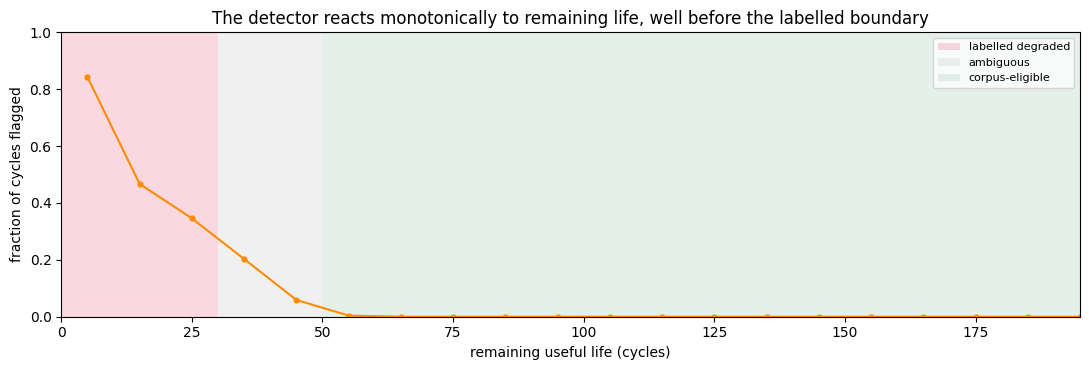

            precision  recall    f1  adj_f1  flagged_frac
LOEO p99.9      0.874   0.544 0.670   0.962         0.093
2x              0.954   0.324 0.483   0.633         0.051
4x              0.984   0.221 0.361   0.528         0.034
8x              1.000   0.134 0.237   0.485         0.020


In [9]:
best = max(results, key=lambda name: results[name]['f1'])
mask = masks[best]

bands = [('degraded   (RUL <= {0})'.format(HEALTH_HORIZON), eval_rul <= HEALTH_HORIZON),
         ('ambiguous  ({0} < RUL <= {1})'.format(HEALTH_HORIZON, CORPUS_RUL_FLOOR),
          (eval_rul > HEALTH_HORIZON) & (eval_rul <= CORPUS_RUL_FLOOR)),
         ('healthy    (RUL > {0})'.format(CORPUS_RUL_FLOOR), eval_rul > CORPUS_RUL_FLOOR)]

print('flag rate by remaining life, at the best threshold ({0}):\n'.format(best))
for label, in_band in bands:
    print('  {0:<32} {1:>6,} cycles   flagged {2:>6.1%}'.format(
        label, int(in_band.sum()), float(mask[in_band].mean())))

# Flag rate against remaining life directly, which shows where the detector starts reacting.
edges = np.arange(0, 210, 10)
centres, rates = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    in_bin = (eval_rul >= lo) & (eval_rul < hi)
    if in_bin.sum() > 50:
        centres.append((lo + hi) / 2)
        rates.append(float(mask[in_bin].mean()))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(centres, rates, marker='o', ms=3.5, color='darkorange')
ax.axvspan(0, HEALTH_HORIZON, color='crimson', alpha=0.16, lw=0, label='labelled degraded')
ax.axvspan(HEALTH_HORIZON, CORPUS_RUL_FLOOR, color='0.6', alpha=0.14, lw=0, label='ambiguous')
ax.axvspan(CORPUS_RUL_FLOOR, max(centres), color='seagreen', alpha=0.12, lw=0,
           label='corpus-eligible')
ax.set_xlabel('remaining useful life (cycles)')
ax.set_ylabel('fraction of cycles flagged')
ax.set_title('The detector reacts monotonically to remaining life, '
             'well before the labelled boundary')
ax.set_xlim(0, max(centres)); ax.set_ylim(0, 1)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

table = pd.DataFrame(results).T[['precision', 'recall', 'f1', 'adj_f1', 'flagged_frac']]
print(table.to_string(float_format=lambda v: '{0:.3f}'.format(v)))


### Where the flags land


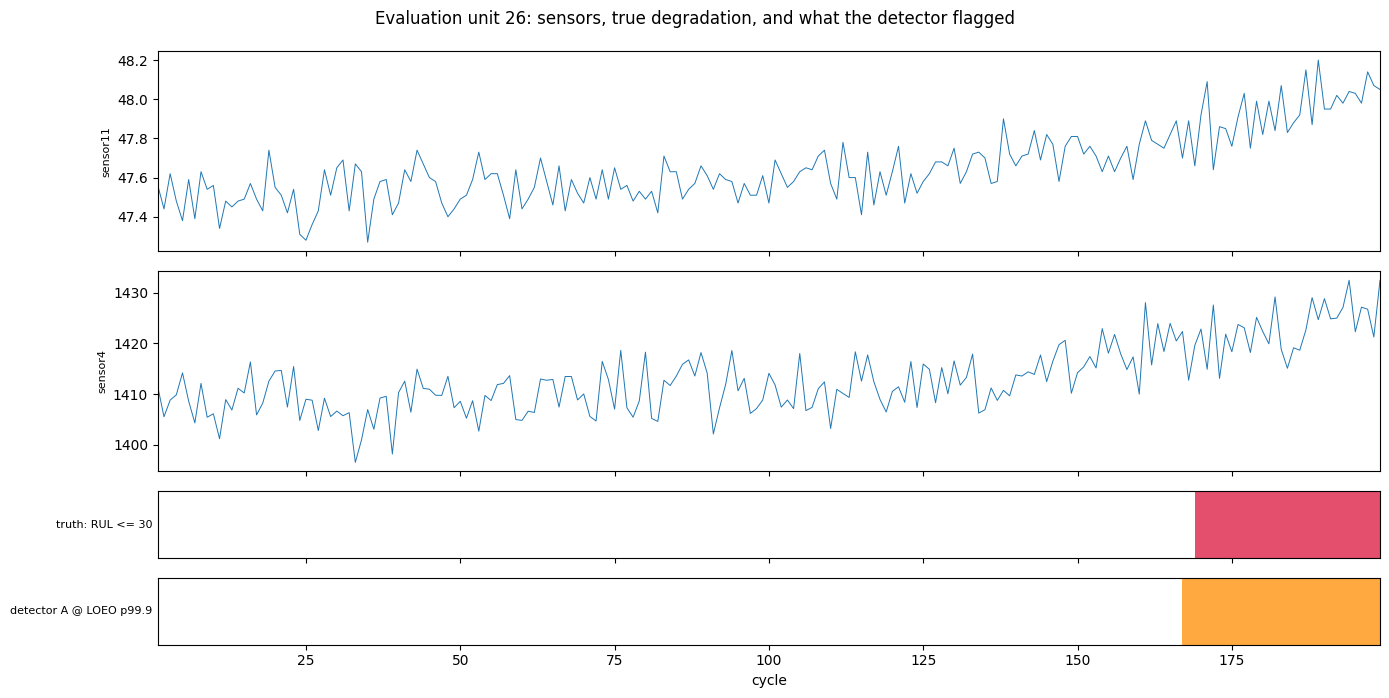

In [10]:
# One engine, its two most informative sensors, with truth and flags underneath. The engine is
# the same median unit plotted in section 1, so the traces are directly comparable.
engine_rows = np.flatnonzero(eval_sorted.unit.to_numpy() == EVAL_UNIT)
sub = eval_sorted.iloc[engine_rows]

fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1, 1]})
for ax, channel in zip(axes[:2], SHOW[:2]):
    ax.plot(sub.cycle, sub[channel], lw=0.7, color='#1f77b4')
    ax.set_ylabel(channel, fontsize=8)
    ax.margins(x=0)

for ax, (series, title, colour) in zip(axes[2:], (
        (truth[engine_rows], 'truth: RUL <= {0}'.format(HEALTH_HORIZON), 'crimson'),
        (mask[engine_rows], 'detector A @ {0}'.format(best), 'darkorange'))):
    for lo, hi in segments(series):
        ax.axvspan(sub.cycle.iloc[lo], sub.cycle.iloc[hi - 1], color=colour, alpha=0.75, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(title, fontsize=8, rotation=0, ha='right', va='center')
    ax.set_xlim(sub.cycle.min(), sub.cycle.max())

axes[-1].set_xlabel('cycle')
fig.suptitle('Evaluation unit {0}: sensors, true degradation, and what the detector '
             'flagged'.format(EVAL_UNIT), y=0.99)
plt.tight_layout()
plt.show()


## 6. Where the detector fires

Three views, answering different questions. The single-engine plot above shows *what* a
detection looks like; these show whether it generalises, and how early it happens.


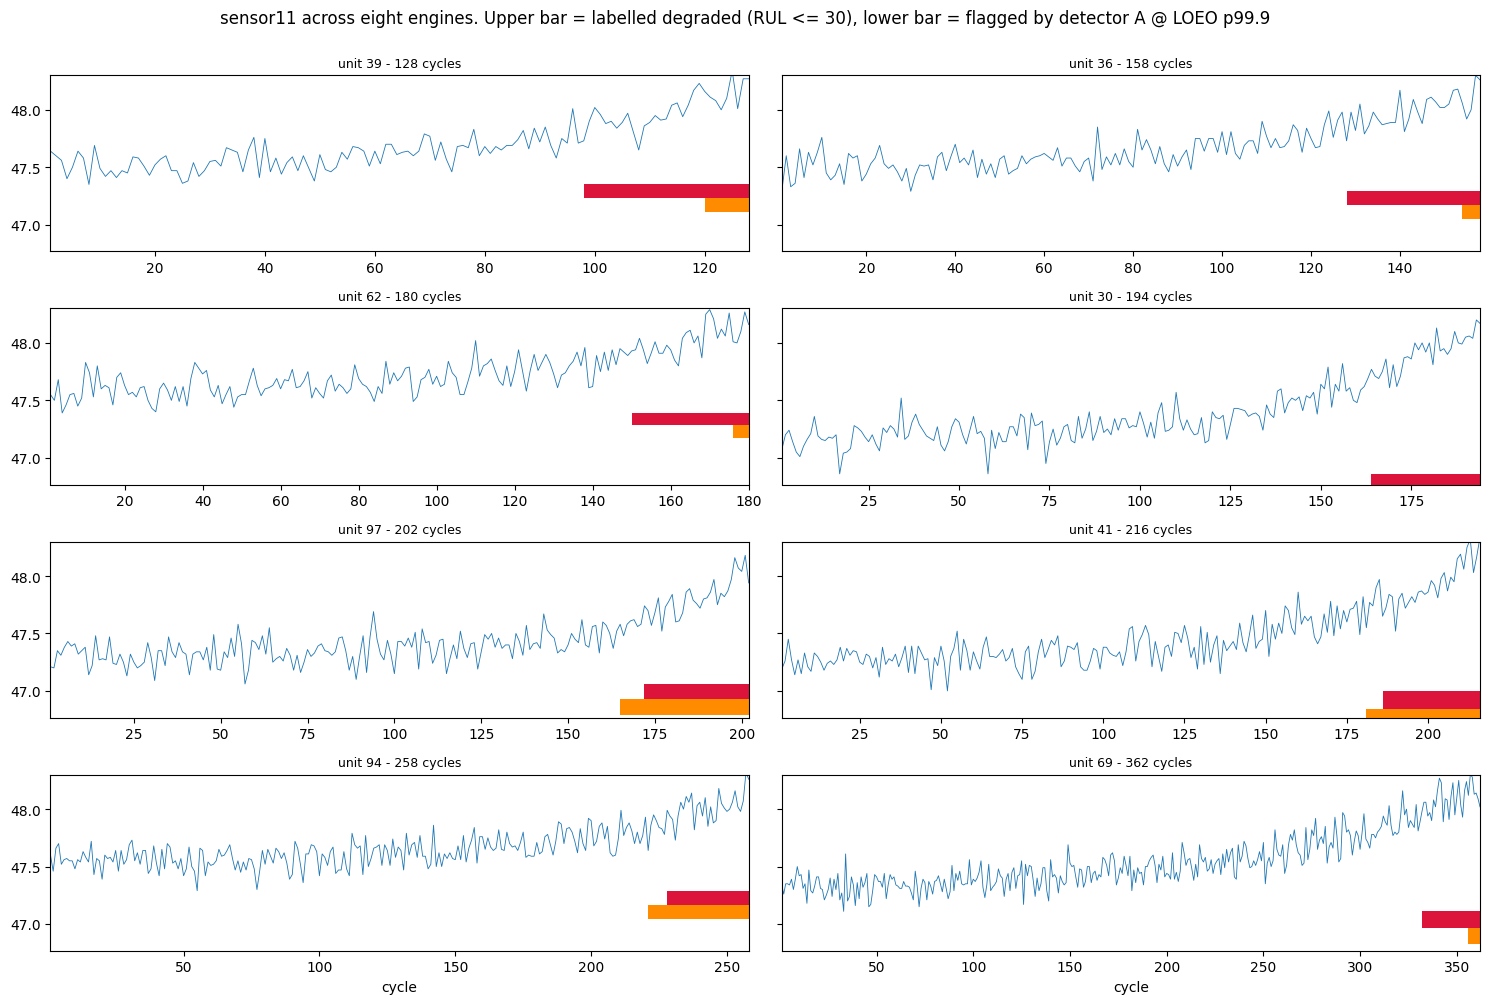

In [11]:
# Eight engines spanning the lifetime range, so the sample is not quietly drawn from one end
# of it. Each panel: the most degradation-sensitive sensor, with the labelled region and the
# flagged region underneath.
lifetimes = eval_sorted.groupby('unit').size().sort_values()
sample = lifetimes.iloc[np.linspace(0, len(lifetimes) - 1, 8).round().astype(int)].index
units = eval_sorted.unit.to_numpy()

fig, axes = plt.subplots(4, 2, figsize=(15, 10), sharey=True)
for ax, unit in zip(axes.ravel(), sample):
    rows = np.flatnonzero(units == unit)
    sub = eval_sorted.iloc[rows]
    ax.plot(sub.cycle, sub[SHOW[0]], lw=0.6, color='#1f77b4')

    low, high = sub[SHOW[0]].min(), sub[SHOW[0]].max()
    pad = (high - low) * 0.12
    for series, colour, offset in ((truth[rows], 'crimson', 0),
                                   (mask[rows], 'darkorange', 1)):
        for lo, hi in segments(series):
            ax.fill_between([sub.cycle.iloc[lo], sub.cycle.iloc[hi - 1]],
                            low - pad * (offset + 1), low - pad * offset,
                            color=colour, lw=0)

    ax.set_title('unit {0} - {1} cycles'.format(unit, len(rows)), fontsize=9)
    ax.margins(x=0)
    ax.set_ylim(low - pad * 2.4, high)

for ax in axes[-1]:
    ax.set_xlabel('cycle')
fig.suptitle('{0} across eight engines. Upper bar = labelled degraded (RUL <= {1}), '
             'lower bar = flagged by detector A @ {2}'.format(
                 SHOW[0], HEALTH_HORIZON, best), y=1.0)
plt.tight_layout()
plt.show()


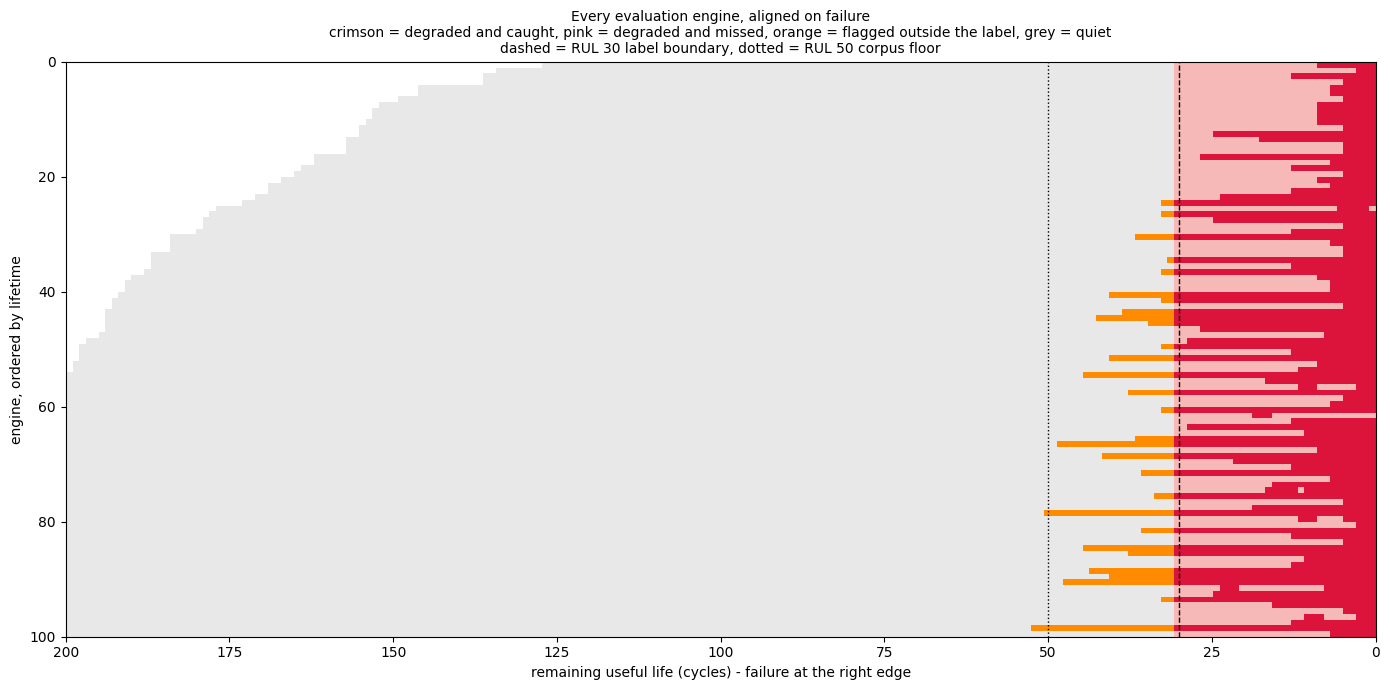

degraded cycles caught 1,685 / missed 1,415  |  flagged outside the label 237


In [12]:
# Every engine at once, aligned on failure rather than on cycle 1. All engines end at RUL 0,
# so this asks whether the detector fires at a consistent distance from failure - which cycle
# it happens on is an accident of how long the unit happened to last.
MAX_RUL = 200
order = eval_sorted.groupby('unit').size().sort_values().index
raster = np.zeros((len(order), MAX_RUL + 1), dtype=int)

for row, unit in enumerate(order):
    rows = np.flatnonzero(units == unit)
    remaining, flagged, degraded = eval_rul[rows], mask[rows], truth[rows]
    keep = remaining <= MAX_RUL
    raster[row, remaining[keep]] = np.where(
        degraded[keep] & flagged[keep], 4,                 # caught
        np.where(degraded[keep], 3,                        # missed
                 np.where(flagged[keep], 2, 1)))           # early / quiet

palette = ListedColormap(['white', '#e8e8e8', 'darkorange', '#f7b8b8', 'crimson'])
fig, ax = plt.subplots(figsize=(14, 7))
# Column j holds RUL j, so the extent must run 0 -> MAX_RUL and the *limits* are what put
# failure on the right. Setting the extent backwards instead mirrors the picture.
ax.imshow(raster, aspect='auto', cmap=palette, vmin=0, vmax=4, interpolation='nearest',
          extent=(0, MAX_RUL, len(order), 0))
ax.set_xlim(MAX_RUL, 0)
ax.axvline(HEALTH_HORIZON, color='k', lw=1.0, ls='--')
ax.axvline(CORPUS_RUL_FLOOR, color='k', lw=1.0, ls=':')
ax.set_xlabel('remaining useful life (cycles) - failure at the right edge')
ax.set_ylabel('engine, ordered by lifetime')
ax.set_title('Every evaluation engine, aligned on failure\n'
             'crimson = degraded and caught, pink = degraded and missed, '
             'orange = flagged outside the label, grey = quiet\n'
             'dashed = RUL {0} label boundary, dotted = RUL {1} corpus floor'.format(
                 HEALTH_HORIZON, CORPUS_RUL_FLOOR), fontsize=10)
plt.tight_layout()
plt.show()

caught = (raster == 4).sum()
print('degraded cycles caught {0:,} / missed {1:,}  |  flagged outside the label {2:,}'.format(
    caught, int((raster == 3).sum()), int((raster == 2).sum())))


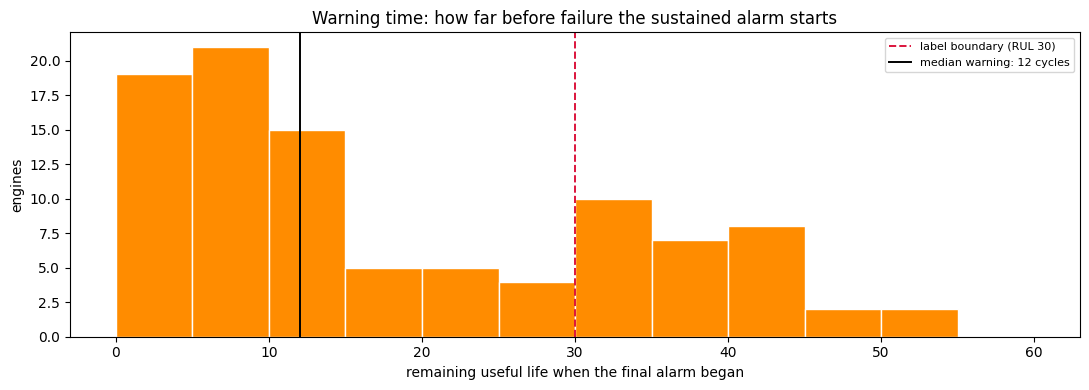

98 engines raise a sustained alarm that persists to failure
2 raise one that clears again, 0 never fire at all
warning time: median 12 cycles, quartiles 6 to 32, earliest 52, latest 2

fires before the label boundary in 30% of engines - the detector is reacting to degradation the 30-cycle convention has not yet called a fault


In [13]:
# How much warning does a flag give? For each engine, take the last run of flagged cycles and
# report the remaining life at its start - the point the alarm came on and stayed on. Engines
# whose alarm does not reach the final cycle are counted separately rather than folded in,
# since a flag that clears before failure is a different event.
onsets, unresolved, silent = [], 0, 0
for unit in order:
    rows = np.flatnonzero(units == unit)
    runs = segments(mask[rows])
    if not runs:
        silent += 1
        continue
    lo, hi = runs[-1]
    if hi < len(rows):
        unresolved += 1
        continue
    onsets.append(int(eval_rul[rows][lo]))

onsets = np.array(onsets)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(onsets, bins=np.arange(0, max(onsets.max() + 10, 60), 5),
        color='darkorange', edgecolor='white')
ax.axvline(HEALTH_HORIZON, color='crimson', lw=1.4, ls='--',
           label='label boundary (RUL {0})'.format(HEALTH_HORIZON))
ax.axvline(float(np.median(onsets)), color='k', lw=1.4,
           label='median warning: {0:.0f} cycles'.format(np.median(onsets)))
ax.set_xlabel('remaining useful life when the final alarm began')
ax.set_ylabel('engines')
ax.set_title('Warning time: how far before failure the sustained alarm starts')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('{0} engines raise a sustained alarm that persists to failure'.format(len(onsets)))
print('{0} raise one that clears again, {1} never fire at all'.format(unresolved, silent))
print('warning time: median {0:.0f} cycles, quartiles {1:.0f} to {2:.0f}, '
      'earliest {3}, latest {4}'.format(
          np.median(onsets), np.percentile(onsets, 25), np.percentile(onsets, 75),
          onsets.max(), onsets.min()))
print('\nfires before the label boundary in {0:.0%} of engines - the detector is reacting to '
      'degradation the {1}-cycle convention has not yet called a fault'.format(
          float((onsets > HEALTH_HORIZON).mean()), HEALTH_HORIZON))


## 7. Does the score track remaining life?

Everything so far has asked a binary question - does this interval exceed its threshold - and
answered it with a search that stops as soon as it finds a clean block. That hides the
underlying quantity. This section drops the search entirely and just measures.

A window of 10 cycles slides along every evaluation engine one cycle at a time. Each position
is signed, whitened and scored against the corpus, and the score is filed under the remaining
life **at the window's last cycle** - the most recent thing it saw, which is what a detector
running online would be reacting to.

If the signature distance is a health indicator, the average of those scores should climb as
remaining life falls, and climb smoothly rather than jumping at the 30-cycle boundary the
labels declare. If it is flat until the last few cycles, the method is detecting failure
rather than predicting it.

Two details worth stating. The corpus holds no 10-point intervals - its widths are 5, 9, 13,
17 and so on - so each window is scored against the depth band whose intervals are closest in
length, which for 10 points out of a 33-point corpus window is depth 2. That is the same rule
`depth_for_width` applies to any interval the search produces that is not a dyadic node.

And at high remaining life only the long-lived engines still have windows, so the average is
taken over a shrinking population. The lower panel shows how many engines contribute at each
point, so a curve that wanders at the right-hand end can be read as thin support rather than
as a finding.


In [14]:
%%time
SLIDE = 10

# One batched FAISS query rather than ~19,000 individual ones. PooledCorpus.score searches a
# single vector at a time, which is right for the widest-first search - it decides what to ask
# next from the answer - but wasteful when every query is known up front.
slide_depth = pooled_final.depth_for_width(SLIDE / WINDOW)

rows, signatures = [], []
for unit, engine in eval_half.sort_values(['unit', 'cycle']).groupby('unit', sort=True):
    values = ((engine[CHANNELS] - LOW) / SPAN).to_numpy()
    rul = engine.rul.to_numpy()

    for lo in range(len(engine) - SLIDE + 1):
        piece = values[lo:lo + SLIDE]
        signatures.append(add_base_point(
            iisignature.sig(piece, TRUNC), piece[0], width, TRUNC))
        rows.append({'unit': int(unit), 'end_rul': int(rul[lo + SLIDE - 1])})

slide = pd.DataFrame(rows)
queries = np.ascontiguousarray(
    (np.asarray(signatures) @ pooled_final.covariance.T).astype('float32'))
slide['score'] = pooled_final._index(slide_depth).search(queries, 1)[0][:, 0]

print('{0:,} window(s) of {1} cycles over {2} engine(s), scored at depth {3}'.format(
    len(slide), SLIDE, slide.unit.nunique(), slide_depth))
print('corpus intervals at that depth are {0} points; the window is {1}'.format(
    9, SLIDE))
print('score: median {0:.1f}, p90 {1:.1f}, max {2:.1f}'.format(
    slide.score.median(), slide.score.quantile(0.9), slide.score.max()))


19,731 window(s) of 10 cycles over 100 engine(s), scored at depth 2
corpus intervals at that depth are 9 points; the window is 10
score: median 216.6, p90 832.3, max 167412.0
CPU times: total: 15.3 s
Wall time: 4.08 s


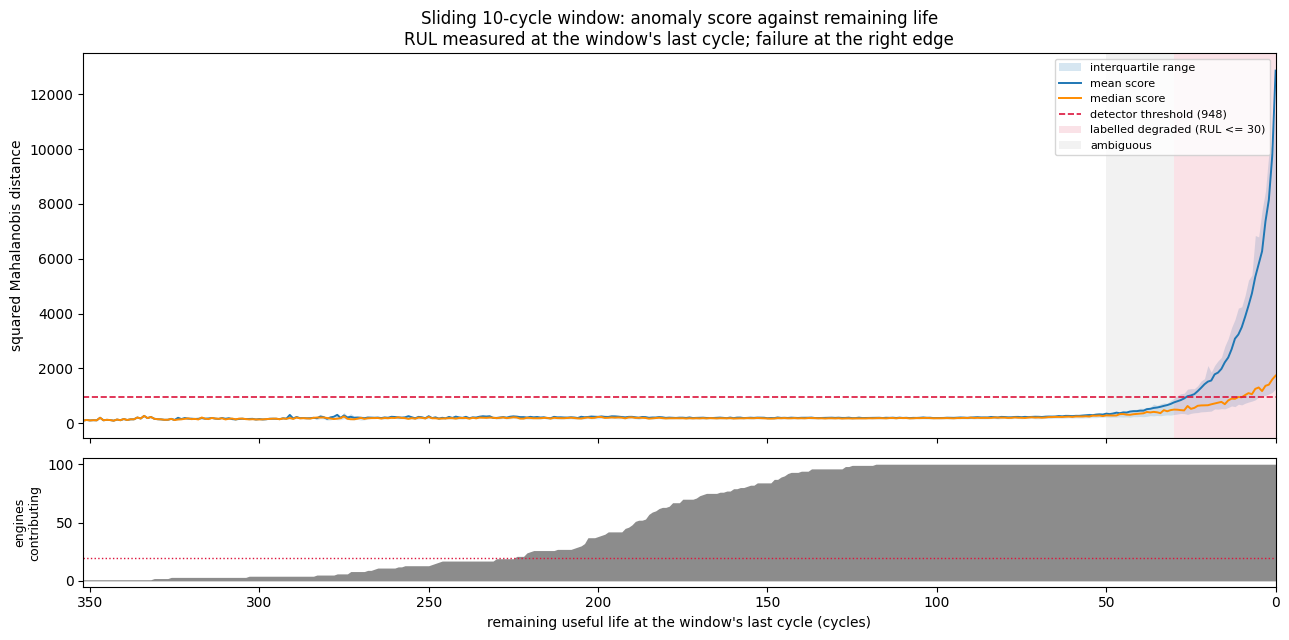

support falls below 20 engines beyond RUL 224

score by remaining life:
  RUL band          mean    median mean/med       n  over thr
  0-10            6846.0    1359.8      5.0   1,000     75.2%
  10-30           1766.1     703.6      2.5   2,000     38.0%
  30-50            498.4     362.2      1.4   2,000     10.3%
  50-100           239.9     212.1      1.1   5,000      0.3%
  100-150          196.6     182.4      1.1   4,839      0.0%
  150-250          208.7     185.4      1.1   4,396      0.1%

degraded / healthy: mean 15.76x, median 4.91x


In [15]:
# Mean score per remaining-life value, with the interquartile band and the engine count that
# supports each point.
curve = slide.groupby('end_rul').agg(
    mean_score=('score', 'mean'),
    median_score=('score', 'median'),
    q25=('score', lambda v: v.quantile(0.25)),
    q75=('score', lambda v: v.quantile(0.75)),
    n_engines=('unit', 'nunique')).reset_index()

fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                                  gridspec_kw={'height_ratios': [3, 1]})

top.fill_between(curve.end_rul, curve.q25, curve.q75, color='#1f77b4', alpha=0.18,
                 lw=0, label='interquartile range')
top.plot(curve.end_rul, curve.mean_score, color='#1f77b4', lw=1.4, label='mean score')
# The mean of a heavy-tailed distribution is not where the typical window sits: a single
# engine at 800,000 moves it and moves nothing else. The median says what most windows do.
top.plot(curve.end_rul, curve.median_score, color='darkorange', lw=1.4, ls='-',
         label='median score')
top.axhline(threshold_pooled, color='crimson', ls='--', lw=1.2,
            label='detector threshold ({0:.0f})'.format(threshold_pooled))
top.axvspan(0, HEALTH_HORIZON, color='crimson', alpha=0.12, lw=0,
            label='labelled degraded (RUL <= {0})'.format(HEALTH_HORIZON))
top.axvspan(HEALTH_HORIZON, CORPUS_RUL_FLOOR, color='0.6', alpha=0.12, lw=0,
            label='ambiguous')
top.set_ylabel('squared Mahalanobis distance')
top.set_title('Sliding {0}-cycle window: anomaly score against remaining life\n'
              'RUL measured at the window\'s last cycle; failure at the right edge'.format(SLIDE))
top.legend(fontsize=8, loc='upper right')

bottom.fill_between(curve.end_rul, 0, curve.n_engines, color='0.55', lw=0)
bottom.set_ylabel('engines\ncontributing', fontsize=9)
bottom.set_xlabel('remaining useful life at the window\'s last cycle (cycles)')
bottom.axhline(20, color='crimson', ls=':', lw=1.0)

for ax in (top, bottom):
    ax.set_xlim(curve.end_rul.max(), 0)     # failure on the right
plt.tight_layout()
plt.show()

full = curve[curve.n_engines >= 20]
print('support falls below 20 engines beyond RUL {0}'.format(int(full.end_rul.max())))
print('\nscore by remaining life:')
print('  {0:<12}{1:>10}{2:>10}{3:>9}{4:>8}{5:>10}'.format(
    'RUL band', 'mean', 'median', 'mean/med', 'n', 'over thr'))
for lo, hi in ((0, 10), (10, 30), (30, 50), (50, 100), (100, 150), (150, 250)):
    band = slide[(slide.end_rul >= lo) & (slide.end_rul < hi)]
    if len(band):
        print('  {0:<12}{1:>10.1f}{2:>10.1f}{3:>9.1f}{4:>8,}{5:>10.1%}'.format(
            '{0}-{1}'.format(lo, hi), band.score.mean(), band.score.median(),
            band.score.mean() / max(band.score.median(), 1e-9), len(band),
            float((band.score > threshold_pooled).mean())))

healthy = slide[slide.end_rul > CORPUS_RUL_FLOOR]
failing = slide[slide.end_rul <= HEALTH_HORIZON]
print('\ndegraded / healthy: mean {0:.2f}x, median {1:.2f}x'.format(
    failing.score.mean() / healthy.score.mean(),
    failing.score.median() / healthy.score.median()))


## 8. The same curve on the other three subsets

Everything so far has been FD001, which is the easiest of the four by some margin: one
operating condition, one fault mode. The other three vary those two factors independently -
FD003 adds a second fault mode, FD002 adds six operating conditions, and FD004 adds both - so
running the same measurement across all four says which of the two the method is sensitive to.

Each subset is rebuilt from scratch: its own min-max scaler, its own corpus of normality, its
own whitening and its own leave-one-engine-out threshold. Nothing else would be honest. A
metric fitted on FD001 places FD002's signatures somewhere meaningless, and the scores are not
comparable across subsets in absolute terms either - each one's distances are measured in its
own whitened space. What *is* comparable is the shape: whether the curve rises as remaining
life falls, and by how much relative to that subset's own healthy level.

The pipeline scored these four at F1 0.592 (FD001), 0.556 (FD003), 0.494 (FD004) and 0.415
(FD002), and the ordering follows operating conditions rather than fault modes. The reason is
visible in the raw data before any detector runs: on FD002 and FD004 every one of the 21
sensors has over 90% of its variance explained by which flight condition the engine is in,
median 100%, against a median of 0% on FD001 and FD003. On the multi-regime subsets a signature
over raw channels is therefore mostly a description of the flight profile, and wear is a small
residual on top of it. These curves are where that either shows up or does not.


In [16]:
%%time
import gc

from sklearn.ensemble import IsolationForest

FOLDS = 5


def kfold_scores(frame, query_units, covariance, folds=FOLDS, band=BAND, seed=0):
    """Score each fold of query engines against the corpus with that whole fold removed.

    The pipeline's protocol - `crossvalidated_thresholding` at `calibrate.folds` - in place of
    the leave-one-engine-out of section 4. It answers the same question, what an engine scores
    when its own history is not in the corpus, and differs only in holding out a fifth of the
    engines at a time rather than one: a reference set of 96 engines instead of 99. `config.yaml`
    records the thresholds moving by under 5% between k=2 and k=100, so this is expected to be
    the smaller of the two changes made here.

    The depths are returned alongside the distances, because the threshold is now taken at the
    width being queried rather than pooled across every width. That is the larger change, and
    section 8b is where it was measured.
    """
    signatures, depths = split_corpus(frame)
    units = frame.unit.to_numpy()
    whitened = (signatures @ covariance.T).astype('float32')

    shuffled = np.random.default_rng(seed).permutation(np.sort(np.asarray(query_units)))
    groups = [group for group in np.array_split(shuffled, folds) if len(group)]

    out = np.full(len(signatures), np.nan)
    for group in groups:
        mine = np.isin(units, group)
        for depth in np.unique(depths[mine]):
            rows = np.flatnonzero(mine & (depths == depth))
            reference = np.flatnonzero(~mine & (np.abs(depths - depth) <= band))
            if reference.size == 0:
                continue
            index = faiss.IndexFlatL2(whitened.shape[1])
            index.add(np.ascontiguousarray(whitened[reference]))
            out[rows] = index.search(np.ascontiguousarray(whitened[rows]), 1)[0][:, 0]

    keep = ~np.isnan(out)
    return out[keep], depths[keep], groups


def subset_health_curve(subset, slide=SLIDE, seed=0):
    """Rebuild the whole detector on one subset and score a sliding window against its RUL.

    Sections 2 to 4 condensed into one function, so the four subsets go through identical code
    rather than through a notebook re-run with a constant changed. Returns the per-RUL curve,
    the raw per-window scores, and the few numbers needed to read them.
    """
    corpus_half, eval_half = DATA[subset]

    # Scaler on corpus-eligible rows only - the same rule as section 2, refitted here because
    # a scaler carried over from another subset would place these channels on the wrong scale.
    usable = corpus_half[corpus_half.healthy]
    low = usable[CHANNELS].min()
    span = (usable[CHANNELS].max() - low).replace(0.0, 1.0)

    def cut(frame, healthy_only):
        frame = frame.sort_values(['unit', 'cycle'])
        blocks, meta = [], []
        for unit, engine in frame.groupby('unit', sort=True):
            values = ((engine[CHANNELS] - low) / span).to_numpy()
            rul = engine.rul.to_numpy()
            length = len(engine)

            starts = list(range(0, length - WINDOW + 1, STRIDE))
            if starts and starts[-1] + WINDOW < length:
                starts.append(length - WINDOW)
            for lo in starts:
                window = slice(lo, lo + WINDOW)
                if healthy_only and not (rul[window] > CORPUS_RUL_FLOOR).all():
                    continue
                blocks.append(values[window].copy())
                meta.append({'unit': int(unit), 'min_rul': int(rul[window].min())})
        return np.stack(blocks), pd.DataFrame(meta)

    corpus_paths, corpus_meta = cut(corpus_half, healthy_only=True)
    pooled = pooled_corpus(corpus_paths, corpus_meta)

    # Fit / withheld over engines, then a k-fold threshold over the withheld ones. Excluding
    # only the exact self is not enough here for the same reason as section 4: overlapping
    # windows leave dozens of near-duplicates of every interval, all from its own engine. The
    # metric is still fitted on the fit engines alone, so the calibration engines are ones it
    # has never seen - that is why the split stays even though the pipeline has dropped it.
    engines = np.sort(corpus_meta.unit.unique())
    shuffled = np.random.default_rng(seed).permutation(engines)
    fit_engines = set(shuffled[:int(round(FIT_FRACTION * len(engines)))].tolist())
    held_engines = [u for u in engines if u not in fit_engines]

    signatures_fit, _ = split_corpus(pooled[pooled.unit.isin(fit_engines)])

    # Rank-reduced at VARIANCE_KEEP, as in section 4. How many directions that leaves, and how
    # well conditioned they are, is a property of the subset rather than of the setting - which
    # is one of the things worth reading across the four.
    whitening, metric = covariance_matrix(
        signatures_fit, variance_keep=VARIANCE_KEEP, form='inv_sqrt')
    singular, usable = spectrum(signatures_fit)

    calibration, cal_depths, folds = kfold_scores(
        pooled, held_engines, whitening, FOLDS, BAND, seed)
    loeo = pd.DataFrame({'depth': cal_depths, 'distance': calibration})

    detector = PooledCorpus(pooled, covariance=whitening, band=BAND, check_scale=False)
    depth = detector.depth_for_width(slide / WINDOW)

    # At the slide window's own depth, not pooled over every width. A level-2 signature term
    # scales like the increment squared, so a pooled tail belongs almost entirely to the widest
    # intervals, and a 10-cycle window judged against it is being compared with intervals it
    # never resembles. Section 8b measured what that cost: 1.3x to 2.2x too high.
    at_depth = calibration[cal_depths == depth]
    threshold = float(np.percentile(at_depth, PERCENTILE))
    pooled_threshold = float(np.percentile(calibration, PERCENTILE))

    # The sliding window itself. Preallocated rather than appended to a list and stacked: on
    # FD004 that is 58,000 signatures of 650 terms, and holding the list and its stacked copy
    # at the same time doubles the peak for no reason.
    ordered = eval_half.sort_values(['unit', 'cycle'])
    counts = ordered.groupby('unit').size()
    total = int((counts - slide + 1).clip(lower=0).sum())

    queries = np.empty((total, signatures_fit.shape[1]))
    units = np.empty(total, dtype=int)
    end_rul = np.empty(total, dtype=int)

    row = 0
    for unit, engine in ordered.groupby('unit', sort=True):
        values = ((engine[CHANNELS] - low) / span).to_numpy()
        rul = engine.rul.to_numpy()
        for lo in range(len(engine) - slide + 1):
            piece = values[lo:lo + slide]
            queries[row] = add_base_point(
                iisignature.sig(piece, TRUNC), piece[0], values.shape[1], TRUNC)
            units[row], end_rul[row] = int(unit), int(rul[lo + slide - 1])
            row += 1

    whitened = np.ascontiguousarray((queries[:row] @ detector.covariance.T).astype('float32'))
    scores = detector._index(depth).search(whitened, 1)[0][:, 0]

    # The same intervals, the same windows, a different question. The distance detector asks
    # how far this window is from the nearest normal one; the forest asks how few random
    # axis-aligned splits isolate it. Fitted on the same whitened band so that nothing but the
    # question differs - and in particular so the two curves below are directly comparable.
    band = np.flatnonzero(np.abs(pooled.depth.to_numpy() - depth) <= BAND)
    band_block = (split_corpus(pooled.iloc[band])[0] @ whitening.T).astype('float32')
    band_units = pooled.unit.to_numpy()[band]

    forest = IsolationForest(n_estimators=200, random_state=seed).fit(band_block)
    # Negated, so larger means more anomalous for both detectors and the plots share a sense.
    forest_scores = -forest.score_samples(whitened)

    # Calibrated on the same folds as the distance threshold, and at this depth only - it is
    # the only one the curve draws. A forest grown on an engine's own intervals has learnt that
    # engine's peculiarities and isolates them less readily, which is the same leak the k-fold
    # exists to close.
    held = []
    for group in folds:
        mine = np.isin(band_units, group)
        if not mine.any() or (~mine).sum() < 50:
            continue
        grown = IsolationForest(n_estimators=200, random_state=seed).fit(band_block[~mine])
        held.extend((-grown.score_samples(band_block[mine])).tolist())
    forest_threshold = float(np.percentile(held, PERCENTILE)) if held else float('nan')

    frame = pd.DataFrame({'unit': units[:row], 'end_rul': end_rul[:row], 'score': scores,
                          'forest': forest_scores})
    curve = frame.groupby('end_rul').agg(
        mean_score=('score', 'mean'),
        median_score=('score', 'median'),
        q25=('score', lambda v: v.quantile(0.25)),
        q75=('score', lambda v: v.quantile(0.75)),
        forest_median=('forest', 'median'),
        forest_q25=('forest', lambda v: v.quantile(0.25)),
        forest_q75=('forest', lambda v: v.quantile(0.75)),
        n_engines=('unit', 'nunique')).reset_index()

    healthy = frame[frame.end_rul > CORPUS_RUL_FLOOR].score
    failing = frame[frame.end_rul <= HEALTH_HORIZON].score

    # A ratio needs a non-zero denominator, and on a badly conditioned metric the healthy
    # median can be exactly zero - which is itself the finding, so it is reported rather than
    # papered over with a small epsilon.
    def ratio(reduce):
        base = reduce(healthy)
        return float(reduce(failing) / base) if base > 0 else float('nan')

    forest_healthy = frame[frame.end_rul > CORPUS_RUL_FLOOR].forest
    forest_failing = frame[frame.end_rul <= HEALTH_HORIZON].forest

    facts = {
        'forest_threshold': forest_threshold,
        'forest_ratio_median': float(forest_failing.median() / forest_healthy.median()),
        'forest_over_degraded': float((forest_failing > forest_threshold).mean()),
        'forest_over_healthy': float((forest_healthy > forest_threshold).mean()),
        'rank': int(metric['rank']),
        'nonzero': int(usable),
        'terms': int(signatures_fit.shape[1]),
        'condition': float(metric['condition_number']),
        'variance_retained': float(metric['variance_retained']),
        'zero_scores': float((frame.score <= 0).mean()),
        'loeo': loeo,
        'corpus_windows': len(corpus_paths),
        'corpus_engines': int(corpus_meta.unit.nunique()),
        'corpus_intervals': len(pooled),
        'threshold': threshold,
        'pooled_threshold': pooled_threshold,
        'n_calibration': int(at_depth.size),
        'depth': int(depth),
        'slide_windows': int(row),
        'healthy_median': float(healthy.median()),
        'ratio_median': ratio(lambda s: s.median()),
        'ratio_mean': ratio(lambda s: s.mean()),
        'over_threshold_degraded': float((failing > threshold).mean()),
        'over_threshold_healthy': float((healthy > threshold).mean()),
    }

    del pooled, detector, corpus_paths, queries, whitened, band_block
    gc.collect()
    return curve, frame, facts


CURVES = {}
for name in SUBSETS:
    CURVES[name] = subset_health_curve(name)
    facts = CURVES[name][2]
    print('{0}  {1:>5,} windows / {2:>3} engines -> {3:>7,} intervals   rank {4:>3} of {5:>3} '
          'non-zero of {6}   condition {7:>8.1e}   threshold {8:>10.3g} at depth {9} over '
          '{10:,} intervals (pooled would be {11:>10.3g}, {12:.2f}x)   zero scores {13:>5.1%}   '
          'degraded/healthy {14:.2f}x (distance) {15:.2f}x (forest)'.format(
              name, facts['corpus_windows'], facts['corpus_engines'],
              facts['corpus_intervals'], facts['rank'], facts['nonzero'], facts['terms'],
              facts['condition'], facts['threshold'], facts['depth'],
              facts['n_calibration'], facts['pooled_threshold'],
              facts['pooled_threshold'] / facts['threshold'], facts['zero_scores'],
              facts['ratio_median'], facts['forest_ratio_median']), flush=True)


FD001    671 windows /  99 engines ->  24,156 intervals   rank 222 of 305 non-zero of 600   condition  8.5e+01   threshold        724 at depth 2 over 882 intervals (pooled would be        948, 1.31x)   zero scores  0.0%   degraded/healthy 4.91x (distance) 1.36x (forest)
FD002  1,714 windows / 252 engines ->  61,704 intervals   rank  19 of 549 non-zero of 600   condition  7.3e+01   threshold         15 at depth 2 over 2,338 intervals (pooled would be       32.3, 2.15x)   zero scores  0.0%   degraded/healthy 11.50x (distance) 1.17x (forest)
FD003    905 windows / 100 engines ->  32,580 intervals   rank 206 of 342 non-zero of 600   condition  9.6e+01   threshold        916 at depth 2 over 1,505 intervals (pooled would be   1.44e+03, 1.57x)   zero scores  0.0%   degraded/healthy 7.93x (distance) 1.46x (forest)
FD004  2,202 windows / 237 engines ->  79,272 intervals   rank  18 of 549 non-zero of 600   condition  7.6e+01   threshold         19 at depth 2 over 3,073 intervals (pooled would be

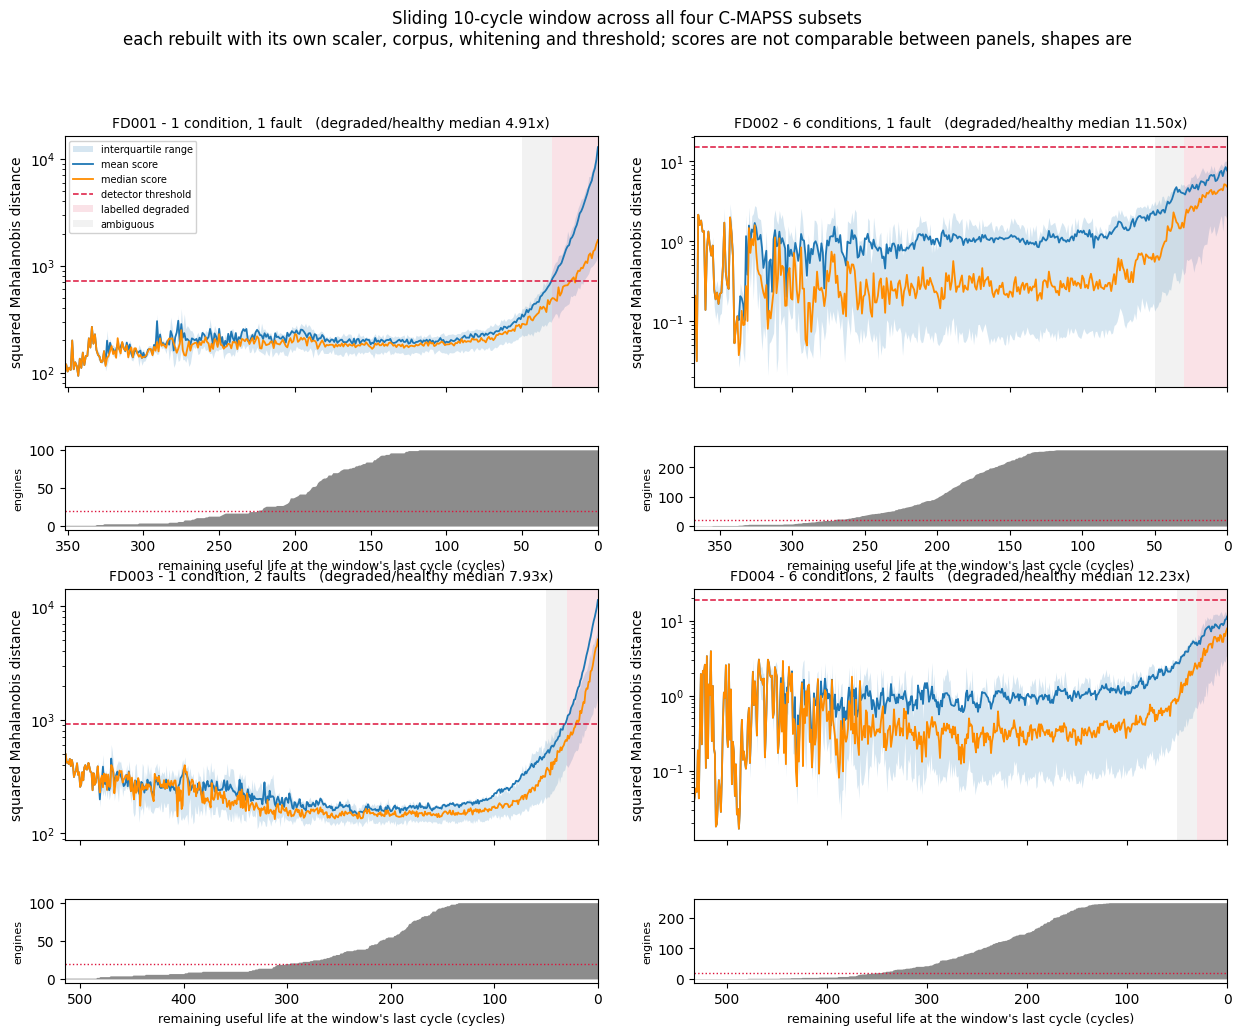

In [17]:
# The section 7 figure, tiled: a score panel over a support panel, one pair per subset.
fig = plt.figure(figsize=(15, 11))
grid = fig.add_gridspec(4, 2, height_ratios=[3, 1, 3, 1], hspace=0.35, wspace=0.18)

REGIMES = {'FD001': '1 condition, 1 fault', 'FD002': '6 conditions, 1 fault',
           'FD003': '1 condition, 2 faults', 'FD004': '6 conditions, 2 faults'}

for position, name in enumerate(SUBSETS):
    curve, _, facts = CURVES[name]
    row, column = (position // 2) * 2, position % 2
    top = fig.add_subplot(grid[row, column])
    bottom = fig.add_subplot(grid[row + 1, column], sharex=top)

    top.fill_between(curve.end_rul, curve.q25, curve.q75, color='#1f77b4', alpha=0.18,
                     lw=0, label='interquartile range')
    top.plot(curve.end_rul, curve.mean_score, color='#1f77b4', lw=1.3, label='mean score')
    top.plot(curve.end_rul, curve.median_score, color='darkorange', lw=1.3,
             label='median score')
    top.axhline(facts['threshold'], color='crimson', ls='--', lw=1.1,
                label='detector threshold')
    top.axvspan(0, HEALTH_HORIZON, color='crimson', alpha=0.12, lw=0,
                label='labelled degraded')
    top.axvspan(HEALTH_HORIZON, CORPUS_RUL_FLOOR, color='0.6', alpha=0.12, lw=0,
                label='ambiguous')

    # Log scale: the distributions are heavy-tailed and the four subsets differ by orders of
    # magnitude, so a shared linear axis would flatten three of the four into the baseline.
    top.set_yscale('log')
    top.set_ylabel('squared Mahalanobis distance')
    top.set_title('{0} - {1}   (degraded/healthy median {2:.2f}x)'.format(
        name, REGIMES[name], facts['ratio_median']), fontsize=10)
    top.tick_params(labelbottom=False)
    if position == 0:
        top.legend(fontsize=7, loc='upper left', framealpha=0.9)

    bottom.fill_between(curve.end_rul, 0, curve.n_engines, color='0.55', lw=0)
    bottom.axhline(20, color='crimson', ls=':', lw=1.0)
    bottom.set_ylabel('engines', fontsize=8)
    bottom.set_xlabel("remaining useful life at the window's last cycle (cycles)", fontsize=9)
    for ax in (top, bottom):
        ax.set_xlim(curve.end_rul.max(), 0)      # failure on the right

fig.suptitle('Sliding {0}-cycle window across all four C-MAPSS subsets\n'
             'each rebuilt with its own scaler, corpus, whitening and threshold; '
             'scores are not comparable between panels, shapes are'.format(SLIDE), y=0.995)
plt.show()


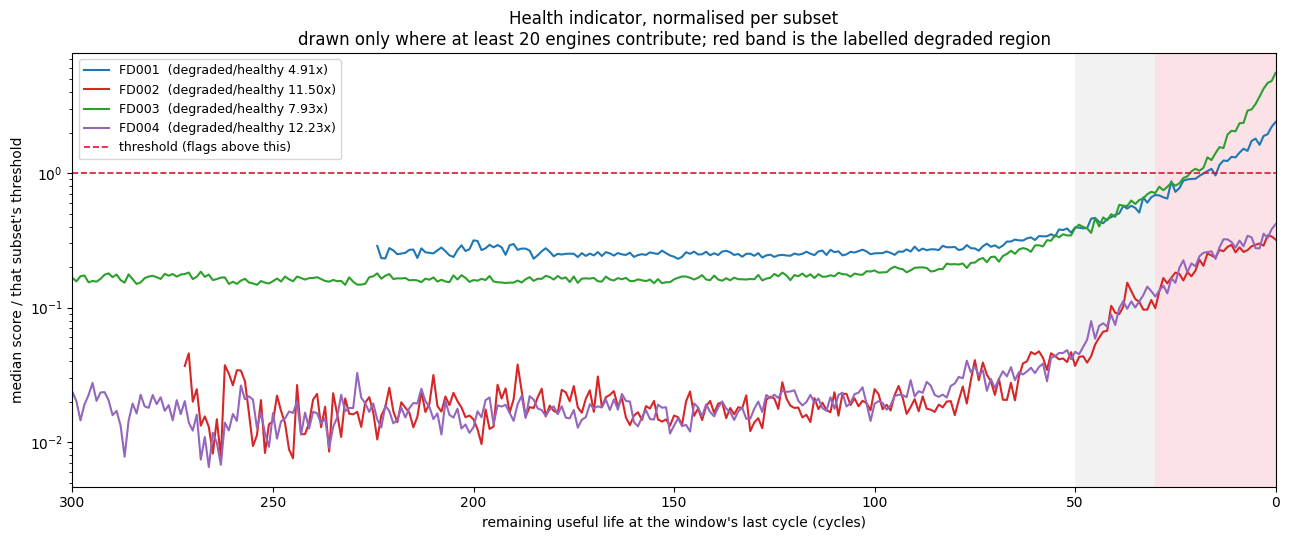

subset      conditions / faults      rank   condition   zero sc.  median x degraded > thr healthy > thr
FD001      1 condition, 1 fault       222     8.5e+01       0.0%      4.91          62.1%          0.5%
FD002     6 conditions, 1 fault        19     7.3e+01       0.0%     11.50           7.7%          0.4%
FD003     1 condition, 2 faults       206     9.6e+01       0.0%      7.93          63.4%          1.1%
FD004    6 conditions, 2 faults        18     7.6e+01       0.0%     12.23           8.6%          0.3%

Separation is the ratio between the two shaded regions - how much further from the corpus a
degraded window sits than a healthy one from the same fleet. A subset whose ratio is near 1.0
has no usable health indicator at this window length, however its F1 happens to read.

Read it alongside the rank and the condition number. The whitening divides by every direction
it keeps, so where the retained subspace is still ill-conditioned the distance is dominated by
directions that a

In [18]:
# The four medians on one axes. Absolute distances are not comparable between subsets - each
# lives in its own whitened space - so each curve is divided by that subset's own threshold.
# The threshold rather than the healthy median, for two reasons: it is the number the detector
# actually compares against, so 1.0 on this axis is exactly the firing point; and it is always
# positive, whereas a healthy median can be zero on a badly conditioned metric.
fig, ax = plt.subplots(figsize=(13, 5.5))
colours = dict(zip(SUBSETS, ('#1f77b4', '#d62728', '#2ca02c', '#9467bd')))

for name in SUBSETS:
    curve, _, facts = CURVES[name]
    supported = curve[curve.n_engines >= 20]
    ax.plot(supported.end_rul, supported.median_score / facts['threshold'],
            color=colours[name], lw=1.5,
            label='{0}  (degraded/healthy {1:.2f}x)'.format(name, facts['ratio_median']))

ax.axhline(1.0, color='crimson', ls='--', lw=1.2, label='threshold (flags above this)')
ax.axvspan(0, HEALTH_HORIZON, color='crimson', alpha=0.12, lw=0)
ax.axvspan(HEALTH_HORIZON, CORPUS_RUL_FLOOR, color='0.6', alpha=0.12, lw=0)
ax.set_yscale('log')
ax.set_xlim(300, 0)
ax.set_xlabel("remaining useful life at the window's last cycle (cycles)")
ax.set_ylabel('median score / that subset\'s threshold')
ax.set_title('Health indicator, normalised per subset\n'
             'drawn only where at least 20 engines contribute; red band is the labelled '
             'degraded region')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('{0:<9}{1:>22}{2:>10}{3:>12}{4:>11}{5:>10}{6:>15}{7:>14}'.format(
    'subset', 'conditions / faults', 'rank', 'condition', 'zero sc.', 'median x',
    'degraded > thr', 'healthy > thr'))
for name in SUBSETS:
    facts = CURVES[name][2]
    print('{0:<9}{1:>22}{2:>10}{3:>12.1e}{4:>11.1%}{5:>10.2f}{6:>15.1%}{7:>14.1%}'.format(
        name, REGIMES[name], facts['rank'], facts['condition'], facts['zero_scores'],
        facts['ratio_median'], facts['over_threshold_degraded'],
        facts['over_threshold_healthy']))

print('\nSeparation is the ratio between the two shaded regions - how much further from the '
      'corpus a\ndegraded window sits than a healthy one from the same fleet. A subset whose '
      'ratio is near 1.0\nhas no usable health indicator at this window length, however its '
      'F1 happens to read.')
print('\nRead it alongside the rank and the condition number. The whitening divides by every '
      'direction\nit keeps, so where the retained subspace is still ill-conditioned the '
      'distance is dominated by\ndirections that are mostly sampling noise - which inflates '
      'the threshold, and can push genuine\nvariation below the float32 resolution of the '
      'distances that survive. VARIANCE_KEEP = {0} is the\nsame cut the pipeline makes, and '
      'the rank it leaves is a property of the subset, not of the\nsetting.'.format(
          VARIANCE_KEEP))


### 8b. Why FD002 and FD004 almost never crossed their threshold

The curves above are drawn against a threshold calibrated the way the pipeline calibrates:
k-fold over engines at `calibrate.folds = 5`, and taken **at the width being queried**. That was
not the notebook's original choice, and this section is why it changed.

The first version of section 8 calibrated leave-one-engine-out and reduced every depth to one
pooled percentile. Under it, FD002 and FD004 separated degraded from healthy by a *larger* factor
than FD001 - 11.5x and 12.2x against 4.91x - while flagging almost nothing: 1.6% and 2.5% of
degraded windows above threshold, against roughly half on the other two. Those two facts cannot
both be about the representation, so the threshold was taken apart.

Two things were wrong with it, and both were about the threshold rather than the score.

**It was pooled across interval widths.** The calibration returns a distance for every interval
at every depth, and `np.percentile(..., 99.9)` reduces all of them to one number. But a depth-0
interval is 27 points and a depth-3 interval is 5, and a level-2 signature term scales like the
increment squared - so the pooled tail belongs almost entirely to the widest intervals. The slide
window is 10 points and is scored at depth 2. It was being judged against a threshold set by
intervals it never resembles. The printout above gives the ratio per subset.

**The percentile is finer than the sample can express.** At depth 2 the calibration sample is a
couple of thousand intervals, and `np.percentile` places p99.9 at index `(n - 1) * 0.999` - so
the threshold sits between the top two or three values. The operating point rests on two
intervals, and inherits everything idiosyncratic about them. Moving to a per-depth threshold does
not fix this; it is a separate knob, and `PERCENTILE` is still 99.9 here against the pipeline's
p95. The table below is what the same scores give at four percentiles.

Neither is specific to the multi-regime subsets. They simply bite hardest where the margin is
thinnest, which is why checking the calibration on FD001 alone did not catch either.

The k-fold change is the smaller of the two: it leaves a reference set of 96 engines rather than
99, and `config.yaml` records thresholds moving by under 5% between k=2 and k=100. The per-depth
change is the one that moves the curves.

In [19]:
# What the pooled percentile was describing, and what the per-depth threshold now used
# instead is built from. The `oracle` row is the ceiling any threshold could reach on these
# scores - chosen with labels, so not an operating point anyone could pick unsupervised.
for name in SUBSETS:
    curve, frame, facts = CURVES[name]
    loeo, depth = facts['loeo'], facts['depth']

    print('=== {0} ===  rank {1}, slide window {2} points -> depth {3}'.format(
        name, facts['rank'], SLIDE, depth))
    print('  {0:<8}{1:>12}{2:>14}{3:>14}'.format('depth', 'n', 'median', 'p99.9'))
    for level in sorted(loeo.depth.unique()):
        values = loeo.distance[loeo.depth == level]
        print('  {0:<8}{1:>12,}{2:>14.4g}{3:>14.4g}{4}'.format(
            level, len(values), float(values.median()),
            float(np.percentile(values, PERCENTILE)),
            '   <- the slide window is scored here' if level == depth else ''))

    at_depth = loeo.distance[loeo.depth == depth].to_numpy()
    print('  pooled across depths p{0} = {1:.4g}   |   at depth {2} alone = {3:.4g}   '
          '({4:.2f}x lower)  <- the second is what the curves above now use'.format(
              PERCENTILE, facts['pooled_threshold'], depth, facts['threshold'],
              facts['pooled_threshold'] / facts['threshold']))

    healthy = frame[frame.end_rul > CORPUS_RUL_FLOOR].score.to_numpy()
    degraded = frame[frame.end_rul <= HEALTH_HORIZON].score.to_numpy()

    print('\n  calibrated at depth {0} instead, over {1:,} intervals:'.format(
        depth, len(at_depth)))
    print('  {0:<10}{1:>12}{2:>10}{3:>9}{4:>9}{5:>16}'.format(
        'statistic', 'threshold', 'recall', 'FPR', 'F1', 'rests on'))
    for percentile in (90, 95, 99, 99.9):
        cut = float(np.percentile(at_depth, percentile))
        tp, fp = float((degraded > cut).sum()), float((healthy > cut).sum())
        recall = tp / len(degraded)
        precision = tp / (tp + fp) if tp + fp else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        above = int((at_depth > cut).sum())
        print('  p{0:<9}{1:>12.4g}{2:>10.1%}{3:>9.2%}{4:>9.3f}{5:>16}'.format(
            percentile, cut, recall, fp / len(healthy), f1,
            '{0} interval(s)'.format(above + 1)))

    # The best F1 any threshold could reach on these scores. Chosen with labels, so not an
    # operating point anyone could pick unsupervised - it is the ceiling calibration is aiming
    # at, and the gap to it is what better calibration is worth.
    order = np.argsort(np.r_[healthy, degraded])
    labels = np.r_[np.zeros(len(healthy)), np.ones(len(degraded))][order]
    tp = np.cumsum(labels[::-1])[::-1]
    fp = np.cumsum((1 - labels)[::-1])[::-1]
    curve_f1 = 2 * tp / (2 * tp + fp + (len(degraded) - tp))
    best = int(np.argmax(curve_f1))
    print('  {0:<10}{1:>12.4g}{2:>10.1%}{3:>9.2%}{4:>9.3f}{5:>16}'.format(
        'oracle', float(np.r_[healthy, degraded][order][best]),
        float(tp[best] / len(degraded)), float(fp[best] / len(healthy)),
        float(curve_f1[best]), 'labels'))
    print()


=== FD001 ===  rank 222, slide window 10 points -> depth 2
  depth              n        median         p99.9
  0                756           374          1043
  1              1,890         254.7         906.5
  2                882         172.3         724.1   <- the slide window is scored here
  3              1,008         134.1         675.1
  pooled across depths p99.9 = 947.7   |   at depth 2 alone = 724.1   (1.31x lower)  <- the second is what the curves above now use

  calibrated at depth 2 instead, over 882 intervals:
  statistic    threshold    recall      FPR       F1        rests on
  p90              265.9     96.7%   17.13%    0.697  90 interval(s)
  p95              318.6     93.2%    8.89%    0.793  46 interval(s)
  p99              642.2     67.3%    0.96%    0.783  10 interval(s)
  p99.9            724.1     62.1%    0.49%    0.755   2 interval(s)
  oracle             401     87.1%    4.37%    0.838          labels

=== FD002 ===  rank 19, slide window 10 points -

### 8c. What the score can do, before any threshold is chosen

Sections 8 and 8b both measure the detector *at an operating point*, and the last two changes
moved that point by 1.3x to 2.2x. It is worth separating the two questions: how well does the
score **order** degraded windows above healthy ones, and how well is the threshold placed on that
ordering? The first is what a ranking metric measures and no threshold can change it.

ROC-AUC is the probability that a randomly chosen degraded window scores above a randomly chosen
healthy one. It is also optimistic when the classes are imbalanced, which they are here, so
PR-AUC (average precision) is reported beside it and should be read against the base rate in the
next column - a useless detector scores the base rate, not 0.5.

Both detectors from section 9 are included, because the comparison between them was previously
made entirely through thresholds and one of them was mis-calibrated.


In [20]:
from sklearn.metrics import average_precision_score, roc_auc_score

# The ambiguous band (HEALTH_HORIZON < RUL <= CORPUS_RUL_FLOOR) is excluded, exactly as it is
# from the recall and FPR columns in 8b - those windows are neither labelled degraded nor
# eligible for the corpus, so scoring them either way would be a guess about the label.
records = []
for name in SUBSETS:
    _, frame, facts = CURVES[name]
    healthy = frame[frame.end_rul > CORPUS_RUL_FLOOR]
    degraded = frame[frame.end_rul <= HEALTH_HORIZON]
    truth = np.r_[np.zeros(len(healthy)), np.ones(len(degraded))]

    for detector, column in (('distance', 'score'), ('forest', 'forest')):
        scores = np.r_[healthy[column].to_numpy(), degraded[column].to_numpy()]
        records.append({
            'subset': name, 'detector': detector,
            'roc_auc': float(roc_auc_score(truth, scores)),
            'pr_auc': float(average_precision_score(truth, scores)),
            'base_rate': float(truth.mean()),
            'n_healthy': len(healthy), 'n_degraded': len(degraded)})

AUC = pd.DataFrame.from_records(records)

print('{0:<9}{1:>22}{2:>12}{3:>10}{4:>10}{5:>12}{6:>12}'.format(
    'subset', 'conditions / faults', 'detector', 'ROC-AUC', 'PR-AUC', 'base rate', 'lift'))
for name in SUBSETS:
    for _, row in AUC[AUC.subset == name].iterrows():
        print('{0:<9}{1:>22}{2:>12}{3:>10.3f}{4:>10.3f}{5:>12.3f}{6:>11.1f}x'.format(
            name if row.detector == 'distance' else '',
            REGIMES[name] if row.detector == 'distance' else '',
            row.detector, row.roc_auc, row.pr_auc, row.base_rate,
            row.pr_auc / row.base_rate))

print('\nLift is PR-AUC over the base rate: what the score buys against flagging at random.')
print('\nRead against the F1 table above. Where ROC-AUC is high but the F1 at p99.9 is low, the'
      '\nordering is sound and the threshold is in the wrong place - which is a calibration'
      '\nproblem and fixable. Where ROC-AUC itself is low, no threshold would have helped and'
      '\nthe representation is what needs to change.')


subset      conditions / faults    detector   ROC-AUC    PR-AUC   base rate        lift
FD001      1 condition, 1 fault    distance     0.976     0.922       0.175        5.3x
                                     forest     0.969     0.903       0.175        5.2x
FD002     6 conditions, 1 fault    distance     0.804     0.536       0.174        3.1x
                                     forest     0.796     0.579       0.174        3.3x
FD003     1 condition, 2 faults    distance     0.974     0.876       0.142        6.2x
                                     forest     0.973     0.882       0.142        6.2x
FD004    6 conditions, 2 faults    distance     0.844     0.579       0.143        4.1x
                                     forest     0.806     0.568       0.143        4.0x

Lift is PR-AUC over the base rate: what the score buys against flagging at random.

Read against the F1 table above. Where ROC-AUC is high but the F1 at p99.9 is low, the
ordering is sound and the threshold 

## 9. The same curve, scored by isolation instead of by distance

Sections 7 and 8 asked one question of each sliding window: how far is it, in the whitened
space, from the nearest interval of the corpus. This section asks a different one of the *same*
windows - how few random axis-aligned splits are needed to isolate it - and plots the two
answers side by side.

Nothing else changes. Same corpus intervals, same whitening, same depth band, same 10-cycle
windows, same leave-one-engine-out calibration at the same percentile. Only the score differs,
which is what makes the comparison worth drawing.

The two are not on a common scale and cannot be: a squared Mahalanobis distance is unbounded
and runs to five figures here, while an isolation score is a normalised path-length statistic
confined to roughly [0.4, 0.7]. Each curve is therefore divided by **its own** threshold, so 1.0
on the vertical axis means "this detector fires" for both, and the shapes can be read against
each other.

What to look for is not which curve is higher - that is fixed by the calibration - but which
rises earlier and more steeply as remaining life falls, and how much of the degraded band each
spends above 1.0. In the pipeline, on FD001, the forest reached point-wise F1 0.733 against the
distance detector's 0.573, with adjusted F1 0.968 against 0.917.


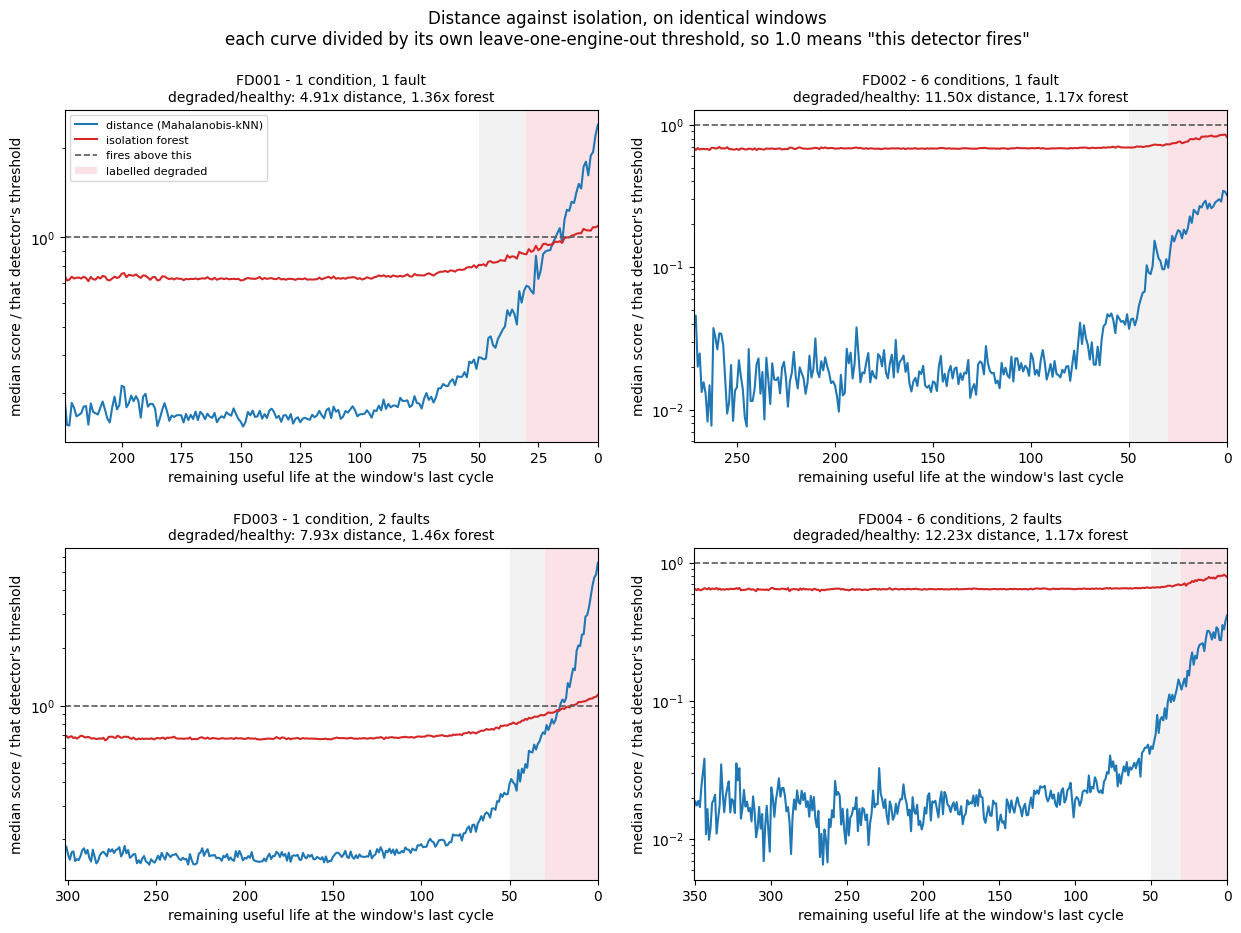

subset      conditions / faults   separation   separation degraded fired  healthy fired
                                    distance       forest  dist / forest  dist / forest
FD001      1 condition, 1 fault         4.91         1.36  62.1% / 49.0%    0.5% / 0.2%
FD002     6 conditions, 1 fault        11.50         1.17    7.7% / 2.8%    0.4% / 0.1%
FD003     1 condition, 2 faults         7.93         1.46  63.4% / 48.7%    1.1% / 0.2%
FD004    6 conditions, 2 faults        12.23         1.17    8.6% / 2.6%    0.3% / 0.1%

Separation is the degraded median over the healthy median, in each detector's own units,
so the two columns are comparable with each other but not with the scores themselves. The
last two columns are what each detector actually flags at its own calibrated threshold -
which is the number that decides whether the separation is usable or merely present.


In [21]:
fig = plt.figure(figsize=(15, 10))
grid = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.18)

for position, name in enumerate(SUBSETS):
    curve, frame, facts = CURVES[name]
    ax = fig.add_subplot(grid[position // 2, position % 2])
    supported = curve[curve.n_engines >= 20]

    # Each detector against its own threshold: 1.0 is where it fires.
    ax.plot(supported.end_rul, supported.median_score / facts['threshold'],
            color='#1f77b4', lw=1.5, label='distance (Mahalanobis-kNN)')
    ax.plot(supported.end_rul, supported.forest_median / facts['forest_threshold'],
            color='#d62728', lw=1.5, label='isolation forest')

    ax.axhline(1.0, color='0.35', ls='--', lw=1.2, label='fires above this')
    ax.axvspan(0, HEALTH_HORIZON, color='crimson', alpha=0.12, lw=0, label='labelled degraded')
    ax.axvspan(HEALTH_HORIZON, CORPUS_RUL_FLOOR, color='0.6', alpha=0.12, lw=0)

    ax.set_yscale('log')
    ax.set_xlim(supported.end_rul.max(), 0)
    ax.set_title('{0} - {1}\ndegraded/healthy: {2:.2f}x distance, {3:.2f}x forest'.format(
        name, REGIMES[name], facts['ratio_median'], facts['forest_ratio_median']), fontsize=10)
    ax.set_xlabel("remaining useful life at the window's last cycle")
    ax.set_ylabel('median score / that detector\'s threshold')
    if position == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Distance against isolation, on identical windows\n'
             'each curve divided by its own leave-one-engine-out threshold, so 1.0 means '
             '"this detector fires"', y=0.98)
plt.show()

print('{0:<9}{1:>22}{2:>13}{3:>13}{4:>15}{5:>15}'.format(
    'subset', 'conditions / faults', 'separation', 'separation', 'degraded fired',
    'healthy fired'))
print('{0:<9}{1:>22}{2:>13}{3:>13}{4:>15}{5:>15}'.format(
    '', '', 'distance', 'forest', 'dist / forest', 'dist / forest'))
for name in SUBSETS:
    facts = CURVES[name][2]
    print('{0:<9}{1:>22}{2:>13.2f}{3:>13.2f}{4:>15}{5:>15}'.format(
        name, REGIMES[name], facts['ratio_median'], facts['forest_ratio_median'],
        '{0:.1%} / {1:.1%}'.format(facts['over_threshold_degraded'],
                                   facts['forest_over_degraded']),
        '{0:.1%} / {1:.1%}'.format(facts['over_threshold_healthy'],
                                   facts['forest_over_healthy'])))

print('\nSeparation is the degraded median over the healthy median, in each detector\'s own '
      'units,\nso the two columns are comparable with each other but not with the scores '
      'themselves. The\nlast two columns are what each detector actually flags at its own '
      'calibrated threshold -\nwhich is the number that decides whether the separation is '
      'usable or merely present.')
